# Q5 six-year future projections

This notebook generates six annual model-based projections of the survey-weighted frequent sport volunteering rate for three borough-level forecasting tasks:

- borough × age group × activity level;
- borough × age group;
- borough × activity level.

The forecasting method, hyperparameters and feature specification for each task were selected previously in the model-comparison notebook. No model or hyperparameter selection is reopened here.

Each selected model is refitted using all available historical waves from Years 3–8. Future rates are then projected recursively from Years 9–14, with each projected rate becoming the one-year lagged input for the following forecast year.

The borough–age–activity projections are also used to derive future active–inactive and fairly-active–inactive volunteering-rate gaps within each borough and age group.

Two post-hoc robustness checks are then used to evaluate the forecasting process: a recursive-horizon backtest and a structural model-family sensitivity analysis. Neither check reopens model selection or replaces the primary point projections.

> **Interpretation boundary.**
> The results are conditional model-based projections. They do not incorporate future policy, demographic or behavioural shocks and should not be interpreted as causal effects or precise population forecasts.

## 1 — Load historical panels and frozen model-selection outputs

The three complete historical panels, the saved selected-model summary and the family-level model-comparison summary are loaded first.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


pd.set_option(
    "display.max_columns",
    100,
)

PROJECT_DIR = Path(
    "/Users/zsh/Downloads/PROJECT/code"
)

DATASET_DIR = (
    PROJECT_DIR
    / "q4_dataset_outputs"
)

MODEL_OUTPUT_DIR = (
    PROJECT_DIR
    / "q4_model_comparison_outputs"
)

MODEL_TABLE_DIR = (
    MODEL_OUTPUT_DIR
    / "tables"
)

MODEL_SUMMARY_PATH = (
    MODEL_OUTPUT_DIR
    / "q5_model_selection_summary.json"
)

MODEL_FAMILY_SUMMARY_PATH = (
    MODEL_TABLE_DIR
    / "q5_cv_model_summary.csv"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "q4_future_forecasting_outputs"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not MODEL_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing model-selection summary: {MODEL_SUMMARY_PATH}"
    )

if not MODEL_FAMILY_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing family-level model summary: {MODEL_FAMILY_SUMMARY_PATH}"
    )

with MODEL_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_selection_summary = (
        json.load(
            file
        )
    )
    
family_model_summary = pd.read_csv(
    MODEL_FAMILY_SUMMARY_PATH,
    low_memory=False,
)

required_family_summary_columns = [
    "task",
    "model",
    "candidate_id",
    "parameters_json",
    "mean_weighted_tv",
]

missing_family_summary_columns = [
    column
    for column in (
        required_family_summary_columns
    )
    if column not in (
        family_model_summary.columns
    )
]

if missing_family_summary_columns:
    raise ValueError(
        "The family-level model summary is "
        f"missing columns: "
        f"{missing_family_summary_columns}"
    )

TARGET = model_selection_summary[
    "target"
]

HISTORICAL_YEARS = [
    int(year)
    for year in model_selection_summary[
        "historical_years"
    ]
]

LAST_HISTORICAL_YEAR = max(
    HISTORICAL_YEARS
)

FUTURE_YEARS = list(
    range(
        LAST_HISTORICAL_YEAR + 1,
        LAST_HISTORICAL_YEAR + 7,
    )
)

TIME_TREND_BASE_YEAR = min(
    HISTORICAL_YEARS
)

LAG_FEATURE = (
    f"{TARGET}_lag1"
)

RANDOM_STATE = int(
    model_selection_summary[
        "random_state"
    ]
)

PREDICTION_LOWER = 0.0
PREDICTION_UPPER = 1.0

SELECTED_TASKS = (
    model_selection_summary[
        "selected_tasks"
    ]
)

TASK_CONFIG = {
    "borough_age_activity": {
        "label": (
            "Borough-age-activity"
        ),
        "path": (
            DATASET_DIR
            / "q5_versionA_borough_age_activitylevel_panel_complete.csv"
        ),
        "expected_rows": 4608,
        "expected_series": 768,
        "series_columns": [
            "series_id",
            "LA_2023",
            "age_group_code",
            "age_group",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
    },
    "borough_age": {
        "label": (
            "Borough-age"
        ),
        "path": (
            DATASET_DIR
            / "q5_versionA_borough_age_panel_complete.csv"
        ),
        "expected_rows": 1536,
        "expected_series": 256,
        "series_columns": [
            "series_id",
            "LA_2023",
            "age_group_code",
            "age_group",
        ],
    },
    "borough_activity": {
        "label": (
            "Borough-activity"
        ),
        "path": (
            DATASET_DIR
            / "q5_versionA_borough_activitylevel_panel_complete.csv"
        ),
        "expected_rows": 576,
        "expected_series": 96,
        "series_columns": [
            "series_id",
            "LA_2023",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
    },
}

if set(
    SELECTED_TASKS
) != set(
    TASK_CONFIG
):
    raise ValueError(
        "The saved model-selection summary does not contain the expected three tasks"
    )

if LAST_HISTORICAL_YEAR != int(
    model_selection_summary[
        "test_year"
    ]
):
    raise ValueError(
        "The final historical year does not match the model-comparison test year"
    )


def load_complete_panel(
    task_name,
    config,
):
    panel_path = config[
        "path"
    ]

    if not panel_path.exists():
        raise FileNotFoundError(
            f"Missing historical panel: "
            f"{panel_path}"
        )

    panel = pd.read_csv(
        panel_path,
        low_memory=False,
    )

    required_columns = [
        "series_id",
        "year",
        "LA_2023",
        TARGET,
        "effective_n_parent_cell"
    ]

    if task_name in [
        "borough_age_activity",
        "borough_age",
    ]:
        required_columns.extend(
            [
                "age_group_code",
                "age_group",
            ]
        )

    if task_name in [
        "borough_age_activity",
        "borough_activity",
    ]:
        required_columns.extend(
            [
                "activity_level_3cat",
                "activity_level_3cat_label",
            ]
        )

    missing_columns = [
        column
        for column in required_columns
        if column not in panel.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{task_name} is missing columns: "
            f"{missing_columns}"
        )

    numeric_columns = [
        "year",
        "LA_2023",
        TARGET,
        "effective_n_parent_cell",
    ]

    for column in [
        "age_group_code",
        "activity_level_3cat",
    ]:
        if column in panel.columns:
            numeric_columns.append(
                column
            )

    for column in numeric_columns:
        panel[column] = (
            pd.to_numeric(
                panel[column],
                errors="coerce",
            )
        )

    if len(panel) != config[
        "expected_rows"
    ]:
        raise ValueError(
            f"{task_name} has an unexpected row count"
        )

    if panel[
        "series_id"
    ].nunique() != config[
        "expected_series"
    ]:
        raise ValueError(
            f"{task_name} has an unexpected number of series"
        )

    if sorted(
        panel[
            "year"
        ]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    ) != HISTORICAL_YEARS:
        raise ValueError(
            f"{task_name} contains unexpected years"
        )

    if panel.duplicated(
        subset=[
            "series_id",
            "year",
        ]
    ).any():
        raise ValueError(
            f"{task_name} contains duplicate series-year rows"
        )

    series_lengths = (
        panel
        .groupby(
            "series_id"
        )
        .size()
    )

    if not series_lengths.eq(
        len(
            HISTORICAL_YEARS
        )
    ).all():
        raise ValueError(
            f"{task_name} series do not all contain six rows"
        )

    observed = panel[
        TARGET
    ].notna()

    if not panel.loc[
        observed,
        TARGET,
    ].between(
        0,
        1,
    ).all():
        raise ValueError(
            f"{task_name} contains an invalid target rate"
        )

    return panel


panels = {}

for task_name, config in (
    TASK_CONFIG.items()
):
    panels[task_name] = (
        load_complete_panel(
            task_name=task_name,
            config=config,
        )
    )

    selected = (
        SELECTED_TASKS[
            task_name
        ]
    )

    print(
        f"{config['label']}: "
        f"{selected['model']} | "
        f"{selected['parameters']}"
    )

Borough-age-activity: Gradient Boosting | {'learning_rate': 0.05, 'loss': 'huber', 'max_depth': 3, 'min_leaf_fraction': 0.02, 'n_estimators': 150}
Borough-age: Gradient Boosting | {'learning_rate': 0.01, 'loss': 'huber', 'max_depth': 2, 'min_leaf_fraction': 0.02, 'n_estimators': 400}
Borough-activity: Random Forest | {'max_depth': 4, 'max_features': 0.5, 'min_leaf_fraction': 0.05, 'n_estimators': 250}


## 2 — Reconstruct the historical modelling features

The historical modelling features are reconstructed separately for the three forecasting tasks using the same definitions as in the model-comparison analysis.

The one-year lag is created within each complete series before rows with unavailable targets are removed. This preserves calendar-year spacing and prevents a missing year from being replaced by an older observation.

All available target rows from Years 3–8 are retained for the final model refit. Missing lag values remain explicit and are handled by the same median-imputation and lag-missing-indicator mechanism used during model development.

Effective sample size and other reliability variables are not used as forecasting predictors.

In [2]:
def add_task_features(
    data,
    task_name,
):
    result = data.copy()

    result[
        "borough_category"
    ] = (
        result[
            "LA_2023"
        ]
        .astype("Int64")
        .astype("string")
    )

    if task_name == (
        "borough_age_activity"
    ):
        result[
            "age_activity_group"
        ] = (
            result[
                "age_group"
            ].astype("string")
            + "__"
            + result[
                "activity_level_3cat_label"
            ].astype("string")
        )

    elif task_name == (
        "borough_age"
    ):
        result[
            "age_group_category"
        ] = (
            result[
                "age_group"
            ].astype("string")
        )

    elif task_name == (
        "borough_activity"
    ):
        result[
            "activity_category"
        ] = (
            result[
                "activity_level_3cat_label"
            ].astype("string")
        )

    else:
        raise ValueError(
            f"Unknown task: "
            f"{task_name}"
        )

    return result


def prepare_model_panel(
    panel,
    task_name,
):
    result = (
        panel
        .sort_values(
            [
                "series_id",
                "year",
            ]
        )
        .reset_index(drop=True)
        .copy()
    )

    result[
        LAG_FEATURE
    ] = (
        result
        .groupby(
            "series_id",
            sort=False,
        )[TARGET]
        .shift(1)
    )

    result[
        "lag_1_available"
    ] = result[
        LAG_FEATURE
    ].notna()

    result[
        "lag_1_missing"
    ] = (
        ~result[
            "lag_1_available"
        ]
    ).astype(int)

    result[
        "time_trend"
    ] = (
        result[
            "year"
        ]
        - TIME_TREND_BASE_YEAR
    )

    result = (
        add_task_features(
            data=result,
            task_name=task_name,
        )
    )

    result[
        "target_available"
    ] = result[
        TARGET
    ].notna()

    return result


model_panels = {}

training_data = {}

training_summary_rows = []

for task_name, panel in (
    panels.items()
):
    model_panel = (
        prepare_model_panel(
            panel=panel,
            task_name=task_name,
        )
    )

    model_panels[
        task_name
    ] = model_panel

    training = (
        model_panel.loc[
            model_panel[
                "target_available"
            ]
        ]
        .copy()
    )

    training_data[
        task_name
    ] = training

    selected = (
        SELECTED_TASKS[
            task_name
        ]
    )

    numeric_features = (
        selected[
            "numeric_features"
        ]
    )

    categorical_features = (
        selected[
            "categorical_features"
        ]
    )

    model_features = (
        numeric_features
        + categorical_features
    )

    missing_features = [
        feature
        for feature in model_features
        if feature not in training.columns
    ]

    if missing_features:
        raise ValueError(
            f"{task_name} is missing selected features: "
            f"{missing_features}"
        )

    if LAG_FEATURE not in (
        numeric_features
    ):
        raise ValueError(
            f"{task_name} does not contain the expected lag feature"
        )

    training_summary_rows.append(
        {
            "task": task_name,
            "training_rows": len(
                training
            ),
            "series": (
                model_panel[
                    "series_id"
                ].nunique()
            ),
            "rows_with_observed_lag": int(
                training[
                    "lag_1_available"
                ].sum()
            ),
            "numeric_features": (
                ", ".join(
                    numeric_features
                )
            ),
            "categorical_features": (
                ", ".join(
                    categorical_features
                )
            ),
        }
    )

training_summary = (
    pd.DataFrame(
        training_summary_rows
    )
)

display(
    training_summary
)

,task,training_rows,series,rows_with_observed_lag,numeric_features,categorical_features
0,borough_age_activity,4290,768,3417,"frequent_volunteer_rate_lag1, lag_1_missing, t...","borough_category, age_activity_group"
1,borough_age,1523,256,1256,"frequent_volunteer_rate_lag1, lag_1_missing, t...","borough_category, age_group_category"
2,borough_activity,576,96,480,"frequent_volunteer_rate_lag1, lag_1_missing, t...","borough_category, activity_category"


## 3 — Create the forecasting pipelines

The preprocessing and estimator definitions used in the model-comparison analysis are recreated without modification.

Missing numeric predictors are median-imputed. Ridge Regression additionally standardises numeric predictors, while categorical predictors are most-frequent-imputed and one-hot encoded.

For Random Forest and Gradient Boosting, the selected minimum leaf fraction is converted to an absolute `min_samples_leaf` value using the final task-specific training size, subject to the same minimum of five observations used during model comparison.

No model or hyperparameter tuning is performed in this notebook.

In [3]:
def resolve_tree_parameters(
    parameters,
    training_rows,
):
    resolved = (
        parameters.copy()
    )

    leaf_fraction = (
        resolved.pop(
            "min_leaf_fraction"
        )
    )

    resolved[
        "min_samples_leaf"
    ] = max(
        5,
        int(
            np.ceil(
                leaf_fraction
                * training_rows
            )
        ),
    )

    return resolved


def build_preprocessor(
    model_name,
    numeric_features,
    categorical_features,
):
    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        )
    ]

    if model_name == (
        "Ridge Regression"
    ):
        numeric_steps.append(
            (
                "scaler",
                StandardScaler(),
            )
        )

    numeric_transformer = (
        Pipeline(
            steps=numeric_steps
        )
    )

    categorical_transformer = (
        Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy=(
                            "most_frequent"
                        )
                    ),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown=(
                            "ignore"
                        ),
                        sparse_output=False,
                    ),
                ),
            ]
        )
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_transformer,
                numeric_features,
            ),
            (
                "categorical",
                categorical_transformer,
                categorical_features,
            ),
        ],
        remainder="drop",
    )


def build_model(
    model_name,
    parameters,
    numeric_features,
    categorical_features,
    training_rows,
):
    preprocessor = (
        build_preprocessor(
            model_name=model_name,
            numeric_features=(
                numeric_features
            ),
            categorical_features=(
                categorical_features
            ),
        )
    )

    if model_name == (
        "Ridge Regression"
    ):
        estimator = Ridge(
            **parameters
        )

    elif model_name == (
        "Random Forest"
    ):
        resolved_parameters = (
            resolve_tree_parameters(
                parameters=parameters,
                training_rows=(
                    training_rows
                ),
            )
        )

        estimator = (
            RandomForestRegressor(
                **resolved_parameters,
                random_state=(
                    RANDOM_STATE
                ),
                n_jobs=-1,
            )
        )

    elif model_name == (
        "Gradient Boosting"
    ):
        resolved_parameters = (
            resolve_tree_parameters(
                parameters=parameters,
                training_rows=(
                    training_rows
                ),
            )
        )

        estimator = (
            GradientBoostingRegressor(
                **resolved_parameters,
                random_state=(
                    RANDOM_STATE
                ),
            )
        )

    else:
        raise ValueError(
            f"Unknown model: "
            f"{model_name}"
        )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

## 4 — Refit the selected models on all historical waves

The frozen model specification for each task is now refitted using every available observed target from Years 3–8.

The model family, hyperparameters and feature set are taken directly from the saved model-selection summary. Effective sample size is not used as a fitting weight because the models in the model-comparison analysis were trained without observation weights; effective sample size was used only in the formal validation metric.

For tree-based models, the selected proportional leaf-size rule is recalculated using the full final training sample for the corresponding task.

In [4]:
fitted_models = {}

fit_summary_rows = []

for task_name, config in (
    TASK_CONFIG.items()
):
    selected = (
        SELECTED_TASKS[
            task_name
        ]
    )

    model_name = (
        selected[
            "model"
        ]
    )

    parameters = (
        selected[
            "parameters"
        ]
    )

    numeric_features = (
        selected[
            "numeric_features"
        ]
    )

    categorical_features = (
        selected[
            "categorical_features"
        ]
    )

    model_features = (
        numeric_features
        + categorical_features
    )

    training = (
        training_data[
            task_name
        ]
    )

    if model_name == (
        "Naive baseline"
    ):
        fitted_model = None

        resolved_parameters = {}

    else:
        fitted_model = (
            build_model(
                model_name=model_name,
                parameters=parameters,
                numeric_features=(
                    numeric_features
                ),
                categorical_features=(
                    categorical_features
                ),
                training_rows=len(
                    training
                ),
            )
        )

        fitted_model.fit(
            training[
                model_features
            ],
            training[
                TARGET
            ],
        )

        if model_name in [
            "Random Forest",
            "Gradient Boosting",
        ]:
            resolved_parameters = (
                resolve_tree_parameters(
                    parameters=parameters,
                    training_rows=len(
                        training
                    ),
                )
            )

        else:
            resolved_parameters = (
                parameters.copy()
            )

    fitted_models[
        task_name
    ] = fitted_model

    fit_summary_rows.append(
        {
            "task": task_name,
            "model": model_name,
            "training_rows": len(
                training
            ),
            "selected_parameters": (
                json.dumps(
                    parameters,
                    sort_keys=True,
                )
            ),
            "resolved_fit_parameters": (
                json.dumps(
                    resolved_parameters,
                    sort_keys=True,
                )
            ),
        }
    )

fit_summary = pd.DataFrame(
    fit_summary_rows
)

display(
    fit_summary
)

,task,model,training_rows,selected_parameters,resolved_fit_parameters
0,borough_age_activity,Gradient Boosting,4290,"{""learning_rate"": 0.05, ""loss"": ""huber"", ""max_...","{""learning_rate"": 0.05, ""loss"": ""huber"", ""max_..."
1,borough_age,Gradient Boosting,1523,"{""learning_rate"": 0.01, ""loss"": ""huber"", ""max_...","{""learning_rate"": 0.01, ""loss"": ""huber"", ""max_..."
2,borough_activity,Random Forest,576,"{""max_depth"": 4, ""max_features"": 0.5, ""min_lea...","{""max_depth"": 4, ""max_features"": 0.5, ""min_sam..."


## 5 — Construct the future series grids

Each forecasting task retains the same series universe as its historical complete panel:

- 768 borough–age–activity series;
- 256 borough–age series;
- 96 borough–activity series.

The observed Year 8 rate is attached to each series as the initial one-year lag for the Year 9 forecast.

If a Year 8 rate is unavailable, the initial lag remains missing. The selected machine-learning pipeline then applies the same median-imputation and lag-missing-indicator mechanism used during model development.

No historical missing value is replaced by an older observed rate in the primary forecast.

In [5]:
def build_series_frame(
    panel,
    task_name,
    config,
):
    series_columns = (
        config[
            "series_columns"
        ]
    )

    series_frame = (
        panel[
            series_columns
        ]
        .drop_duplicates()
        .sort_values(
            "series_id"
        )
        .reset_index(drop=True)
    )

    if len(series_frame) != config[
        "expected_series"
    ]:
        raise ValueError(
            f"{task_name} has an unexpected future series count"
        )

    if series_frame[
        "series_id"
    ].duplicated().any():
        raise ValueError(
            f"{task_name} contains inconsistent series metadata"
        )

    year8_baseline = (
        panel.loc[
            panel[
                "year"
            ].eq(
                LAST_HISTORICAL_YEAR
            ),
            [
                "series_id",
                TARGET,
            ],
        ]
        .rename(
            columns={
                TARGET: (
                    "year8_observed_rate"
                )
            }
        )
    )

    if year8_baseline[
        "series_id"
    ].duplicated().any():
        raise ValueError(
            f"{task_name} contains duplicate Year 8 series"
        )

    series_frame = (
        series_frame
        .merge(
            year8_baseline,
            on="series_id",
            how="left",
            validate="one_to_one",
        )
    )

    series_frame[
        "initial_year8_lag_observed"
    ] = series_frame[
        "year8_observed_rate"
    ].notna()

    series_frame[
        "task"
    ] = task_name

    return series_frame


series_frames = {}

series_summary_rows = []

for task_name, config in (
    TASK_CONFIG.items()
):
    series_frame = (
        build_series_frame(
            panel=panels[
                task_name
            ],
            task_name=task_name,
            config=config,
        )
    )

    series_frames[
        task_name
    ] = series_frame

    series_summary_rows.append(
        {
            "task": task_name,
            "series": len(
                series_frame
            ),
            "observed_year8_lag": int(
                series_frame[
                    "initial_year8_lag_observed"
                ].sum()
            ),
            "missing_year8_lag": int(
                (
                    ~series_frame[
                        "initial_year8_lag_observed"
                    ]
                ).sum()
            ),
        }
    )

series_summary = pd.DataFrame(
    series_summary_rows
)

display(
    series_summary
)

,task,series,observed_year8_lag,missing_year8_lag
0,borough_age_activity,768,716,52
1,borough_age,256,255,1
2,borough_activity,96,96,0


## 6 — Generate recursive point projections

The selected task-specific models are used to generate six annual point projections for Years 9–14.

For Year 9, the lagged predictor is the observed Year 8 rate when available. A missing Year 8 lag remains missing and is handled by the fitted preprocessing pipeline.

From Year 10 onwards, the previous year's model projection becomes the lagged predictor for the next forecast year.

Models are not refitted using projected observations. Each selected model is fitted once on the observed Years 3–8 data and then held fixed throughout the six-year recursive projection horizon.

All predicted rates are clipped to the valid probability range \([0,1]\), while the corresponding unclipped predictions are retained for diagnostic purposes.

In [6]:
def make_forecast_rows(
    task_name,
    series_data,
    year,
    lag_values,
    lag_missing,
):
    rows = (
        series_data
        .copy()
    )

    rows[
        "year"
    ] = int(
        year
    )

    rows[
        "forecast_horizon"
    ] = int(
        year
        - LAST_HISTORICAL_YEAR
    )

    rows[
        LAG_FEATURE
    ] = np.asarray(
        lag_values,
        dtype=float,
    )

    rows[
        "lag_1_missing"
    ] = (
        np.asarray(
            lag_missing,
            dtype=bool,
        )
        .astype(int)
    )

    rows[
        "time_trend"
    ] = (
        rows[
            "year"
        ]
        - TIME_TREND_BASE_YEAR
    )

    rows = (
        add_task_features(
            data=rows,
            task_name=task_name,
        )
    )

    return rows


def predict_with_model(
    task_name,
    model,
    data,
):
    selected = (
        SELECTED_TASKS[
            task_name
        ]
    )

    model_name = (
        selected[
            "model"
        ]
    )

    model_features = (
        selected[
            "numeric_features"
        ]
        + selected[
            "categorical_features"
        ]
    )

    if model_name == (
        "Naive baseline"
    ):
        raw_prediction = (
            data[
                LAG_FEATURE
            ]
            .to_numpy(
                dtype=float
            )
        )

    else:
        raw_prediction = (
            np.asarray(
                model.predict(
                    data[
                        model_features
                    ]
                ),
                dtype=float,
            )
            .reshape(-1)
        )

    prediction = np.clip(
        raw_prediction,
        PREDICTION_LOWER,
        PREDICTION_UPPER,
    )

    return (
        prediction,
        raw_prediction,
    )


def recursive_forecast(
    task_name,
    model,
    series_data,
):
    selected = (
        SELECTED_TASKS[
            task_name
        ]
    )

    model_name = (
        selected[
            "model"
        ]
    )

    lag_values = (
        series_data[
            "year8_observed_rate"
        ]
        .to_numpy(
            dtype=float
        )
    )

    lag_missing = (
        np.isnan(
            lag_values
        )
    )

    forecast_parts = []

    for index, year in enumerate(
        FUTURE_YEARS
    ):
        rows = (
            make_forecast_rows(
                task_name=task_name,
                series_data=series_data,
                year=year,
                lag_values=lag_values,
                lag_missing=lag_missing,
            )
        )

        (
            prediction,
            raw_prediction,
        ) = predict_with_model(
            task_name=task_name,
            model=model,
            data=rows,
        )

        rows[
            "selected_model"
        ] = model_name

        rows[
            "raw_predicted_rate"
        ] = raw_prediction

        rows[
            "predicted_rate"
        ] = prediction

        rows[
            "was_clipped"
        ] = (
            np.isfinite(
                raw_prediction
            )
            & (
                (
                    raw_prediction
                    < PREDICTION_LOWER
                )
                | (
                    raw_prediction
                    > PREDICTION_UPPER
                )
            )
        )

        if index == 0:
            rows[
                "lag_source"
            ] = np.where(
                lag_missing,
                "missing_year8",
                "observed_year8",
            )

        else:
            rows[
                "lag_source"
            ] = np.where(
                lag_missing,
                (
                    "unavailable_previous_"
                    "projection"
                ),
                "predicted_previous_year",
            )

        forecast_parts.append(
            rows
        )

        lag_values = (
            prediction
        )

        lag_missing = (
            np.isnan(
                prediction
            )
        )

    result = (
        pd.concat(
            forecast_parts,
            ignore_index=True,
        )
        .sort_values(
            [
                "year",
                "series_id",
            ]
        )
        .reset_index(drop=True)
    )

    result[
        "predicted_rate_pp"
    ] = (
        100
        * result[
            "predicted_rate"
        ]
    )

    result[
        "change_from_year8_pp"
    ] = (
        100
        * (
            result[
                "predicted_rate"
            ]
            - result[
                "year8_observed_rate"
            ]
        )
    )

    return result

future_projections_by_task = {}

for task_name in (
    TASK_CONFIG
):
    future_projections_by_task[
        task_name
    ] = (
        recursive_forecast(
            task_name=task_name,
            model=fitted_models[
                task_name
            ],
            series_data=series_frames[
                task_name
            ],
        )
    )

future_projections = (
    pd.concat(
        [
            future_projections_by_task[
                task_name
            ]
            for task_name in TASK_CONFIG
        ],
        ignore_index=True,
    )
)

point_forecast_summary = (
    future_projections
    .groupby(
        [
            "task",
            "year",
        ],
        as_index=False,
    )
    .agg(
        cells=(
            "series_id",
            "count",
        ),
        available_predictions=(
            "predicted_rate",
            "count",
        ),
        mean_rate=(
            "predicted_rate",
            "mean",
        ),
        median_rate=(
            "predicted_rate",
            "median",
        ),
        min_rate=(
            "predicted_rate",
            "min",
        ),
        max_rate=(
            "predicted_rate",
            "max",
        ),
        clipped_predictions=(
            "was_clipped",
            "sum",
        ),
    )
)

display(
    point_forecast_summary
)

,task,year,cells,available_predictions,mean_rate,median_rate,min_rate,max_rate,clipped_predictions
0,borough_activity,9,96,96,0.096308,0.082540,0.067975,0.138183,0
1,borough_activity,10,96,96,0.094892,0.077140,0.069990,0.136979,0
2,borough_activity,11,96,96,0.095646,0.080786,0.069990,0.136835,0
3,borough_activity,12,96,96,0.094900,0.077204,0.069990,0.136835,0
4,borough_activity,13,96,96,0.095647,0.080786,0.069990,0.136835,0
5,borough_activity,14,96,96,0.094900,0.077204,0.069990,0.136835,0
6,borough_age,9,256,256,0.101092,0.102122,0.019038,0.166988,0
7,borough_age,10,256,256,0.101043,0.102122,0.019038,0.166988,0
8,borough_age,11,256,256,0.101043,0.102122,0.019038,0.166988,0
9,borough_age,12,256,256,0.101043,0.102122,0.019038,0.166988,0


## 7 — Derive projected activity-level gaps

The borough–age–activity point projections are used to derive future activity-level contrasts within the same year, borough and age group.

The primary contrast is:

$$
\text{Active–inactive gap}
=
\hat{p}_{\mathrm{active}}
-
\hat{p}_{\mathrm{inactive}}.
$$

The secondary contrast is:

$$
\text{Fairly active–inactive gap}
=
\hat{p}_{\mathrm{fairly\ active}}
-
\hat{p}_{\mathrm{inactive}}.
$$

Both contrasts are reported in percentage points.

These are contrasts between independently projected activity-level cells within the same borough and age group. They describe differences in projected volunteering rates and do not represent causal effects of activity level.

In [7]:
baa_future = (
    future_projections_by_task[
        "borough_age_activity"
    ]
    .copy()
)

gap_index_columns = [
    "year",
    "forecast_horizon",
    "LA_2023",
    "age_group_code",
    "age_group",
]

if baa_future.duplicated(
    subset=(
        gap_index_columns
        + [
            "activity_level_3cat"
        ]
    )
).any():
    raise ValueError(
        "Duplicate borough-age-activity future cells found"
    )

activity_rate_wide = (
    baa_future
    .pivot(
        index=(
            gap_index_columns
        ),
        columns=(
            "activity_level_3cat"
        ),
        values=(
            "predicted_rate"
        ),
    )
)

required_activity_levels = {
    0,
    1,
    2,
}

if not required_activity_levels.issubset(
    set(
        activity_rate_wide.columns
    )
):
    raise ValueError(
        "The future borough-age-activity projections do not contain all three activity levels"
    )

activity_rate_wide = (
    activity_rate_wide[
        [
            0,
            1,
            2,
        ]
    ]
    .rename(
        columns={
            0: "inactive_rate",
            1: "fairly_active_rate",
            2: "active_rate",
        }
    )
    .reset_index()
)

activity_rate_wide[
    "active_inactive_gap_pp"
] = (
    100
    * (
        activity_rate_wide[
            "active_rate"
        ]
        - activity_rate_wide[
            "inactive_rate"
        ]
    )
)

activity_rate_wide[
    "fairly_active_inactive_gap_pp"
] = (
    100
    * (
        activity_rate_wide[
            "fairly_active_rate"
        ]
        - activity_rate_wide[
            "inactive_rate"
        ]
    )
)

future_activity_gaps = (
    activity_rate_wide
    .sort_values(
        [
            "year",
            "LA_2023",
            "age_group_code",
        ]
    )
    .reset_index(drop=True)
)

gap_summary = (
    future_activity_gaps
    .groupby(
        [
            "year",
            "age_group_code",
            "age_group",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        mean_active_inactive_gap_pp=(
            "active_inactive_gap_pp",
            "mean",
        ),
        median_active_inactive_gap_pp=(
            "active_inactive_gap_pp",
            "median",
        ),
        mean_fairly_active_inactive_gap_pp=(
            "fairly_active_inactive_gap_pp",
            "mean",
        ),
        median_fairly_active_inactive_gap_pp=(
            "fairly_active_inactive_gap_pp",
            "median",
        ),
    )
)

display(
    gap_summary
)

,year,age_group_code,age_group,boroughs,mean_active_inactive_gap_pp,median_active_inactive_gap_pp,mean_fairly_active_inactive_gap_pp,median_fairly_active_inactive_gap_pp
0,9,2,16-24,32,9.234996,8.961886,-2.048020e+00,-1.449794
1,9,3,25-34,32,3.783937,3.369480,-6.374935e-01,-0.054815
2,9,4,35-44,32,5.563259,5.168877,-3.924439e-01,-0.104808
3,9,5,45-54,32,9.244873,9.580854,2.266992e-02,0.229734
4,9,6,55-64,32,6.236011,6.651537,-1.147865e-01,0.000000
5,9,7,65-74,32,7.230137,7.813129,4.825522e-01,0.723585
6,9,8,75-84,32,4.490390,4.649947,-1.021968e+00,-0.601859
7,9,9,85+,32,0.648677,0.573088,1.349528e+00,1.294059
8,10,2,16-24,32,7.677867,7.566956,-1.810382e+00,-1.825117
9,10,3,25-34,32,3.155309,2.945572,-1.900676e-01,0.000000


## 8 — Validate and save the point-projection outputs

The three task-specific point-projection tables and the derived borough–age activity-gap table are validated before any uncertainty analysis or sensitivity checks are introduced.

The checks confirm the expected six-year forecast horizon, complete future series grids, valid probability bounds and unique future cells.

These saved tables form the primary point-projection outputs. Later uncertainty and sensitivity analyses do not redefine the selected models or replace these primary projections.

In [8]:
for task_name, config in (
    TASK_CONFIG.items()
):
    projections = (
        future_projections_by_task[
            task_name
        ]
    )

    expected_rows = (
        config[
            "expected_series"
        ]
        * len(
            FUTURE_YEARS
        )
    )

    if len(
        projections
    ) != expected_rows:
        raise ValueError(
            f"{task_name} has an unexpected number of future rows"
        )

    if sorted(
        projections[
            "year"
        ]
        .unique()
        .tolist()
    ) != FUTURE_YEARS:
        raise ValueError(
            f"{task_name} contains unexpected future years"
        )

    if projections.duplicated(
        subset=[
            "series_id",
            "year",
        ]
    ).any():
        raise ValueError(
            f"{task_name} contains duplicate future series-year rows"
        )

    if projections[
        "predicted_rate"
    ].isna().any():
        raise ValueError(
            f"{task_name} contains missing future predictions"
        )

    if not projections[
        "predicted_rate"
    ].between(
        PREDICTION_LOWER,
        PREDICTION_UPPER,
    ).all():
        raise ValueError(
            f"{task_name} contains an invalid projected rate"
        )

    yearly_counts = (
        projections
        .groupby(
            "year"
        )
        .size()
    )

    if not yearly_counts.eq(
        config[
            "expected_series"
        ]
    ).all():
        raise ValueError(
            f"{task_name} contains an incomplete future-year grid"
        )

expected_gap_rows = (
    32
    * 8
    * len(
        FUTURE_YEARS
    )
)

if len(
    future_activity_gaps
) != expected_gap_rows:
    raise ValueError(
        "The future activity-gap table has an unexpected row count"
    )

if future_activity_gaps.duplicated(
    subset=[
        "year",
        "LA_2023",
        "age_group_code",
    ]
).any():
    raise ValueError(
        "The future activity-gap table contains duplicate cells"
    )

print(
    "All Q5 point-projection checks passed."
)

output_tables = {
    "q5_future_borough_age_activity_point_projections.csv":
        future_projections_by_task[
            "borough_age_activity"
        ],
    "q5_future_borough_age_point_projections.csv":
        future_projections_by_task[
            "borough_age"
        ],
    "q5_future_borough_activity_point_projections.csv":
        future_projections_by_task[
            "borough_activity"
        ],
    "q5_future_activity_level_gaps_point.csv":
        future_activity_gaps,
    "q5_point_forecast_summary.csv":
        point_forecast_summary,
    "q5_activity_gap_summary.csv":
        gap_summary,
    "q5_final_fit_summary.csv":
        fit_summary,
}

for filename, dataframe in (
    output_tables.items()
):
    output_path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved table: "
        f"{output_path}"
    )

All Q5 point-projection checks passed.
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_future_borough_age_activity_point_projections.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_future_borough_age_point_projections.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_future_borough_activity_point_projections.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_future_activity_level_gaps_point.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_point_forecast_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_activity_gap_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_final_fit_summary.csv


## 9 — Recursive-horizon backtest

The selected model family, hyperparameters and feature specification remain frozen for each task.

To assess whether the one-step model-development evidence remains informative under recursive multi-step use, the selected specification is refitted at four historical forecast origins:

- Years 3–4 → recursively predict Years 5–8;
- Years 3–5 → recursively predict Years 6–8;
- Years 3–6 → recursively predict Years 7–8;
- Years 3–7 → predict Year 8.

At each origin, only target observations available up to and including the origin year are used for model fitting. The first forecast uses the observed origin-year rate as the lag when available. All subsequent horizons use the model's own previous projection rather than the later observed rate, reproducing the recursive mechanism used for Years 9–14.

Metrics are first calculated separately for each origin–target pair. Effective-n-weighted TV is calculated within each target wave, after which horizon summaries take arithmetic means across the available origins so that validation waves receive equal weight. Unweighted MAE, RMSE and signed mean error are also reported in percentage points.

This is a forecast-behaviour diagnostic rather than a new model-selection procedure. Because the selected specifications were developed using Years 5–7, backtests involving those waves are post-selection diagnostics rather than fully selection-independent tests. In addition, the six historical waves allow direct recursive evaluation only to horizon 4, whereas the final projections extend to horizon 6.

In [9]:
BACKTEST_ORIGINS = (
    HISTORICAL_YEARS[
        1:-1
    ]
)


def fit_selected_model_to_origin(
    task_name,
    origin_year,
):
    selected = (
        SELECTED_TASKS[
            task_name
        ]
    )

    training = (
        model_panels[
            task_name
        ]
        .loc[
            (
                model_panels[
                    task_name
                ][
                    "target_available"
                ]
            )
            & (
                model_panels[
                    task_name
                ][
                    "year"
                ]
                <= origin_year
            )
        ]
        .copy()
    )

    if selected[
        "model"
    ] == "Naive baseline":
        return None

    model_features = (
        selected[
            "numeric_features"
        ]
        + selected[
            "categorical_features"
        ]
    )

    model = (
        build_model(
            model_name=selected[
                "model"
            ],
            parameters=selected[
                "parameters"
            ],
            numeric_features=selected[
                "numeric_features"
            ],
            categorical_features=selected[
                "categorical_features"
            ],
            training_rows=len(
                training
            ),
        )
    )

    model.fit(
        training[
            model_features
        ],
        training[
            TARGET
        ],
    )

    return model


def recursive_historical_backtest(
    task_name,
    origin_year,
):
    panel = (
        panels[
            task_name
        ]
    )

    config = (
        TASK_CONFIG[
            task_name
        ]
    )

    model = (
        fit_selected_model_to_origin(
            task_name=task_name,
            origin_year=origin_year,
        )
    )

    series_data = (
        panel[
            config[
                "series_columns"
            ]
        ]
        .drop_duplicates()
        .sort_values(
            "series_id"
        )
        .reset_index(drop=True)
    )

    origin_rate = (
        panel.loc[
            panel[
                "year"
            ].eq(
                origin_year
            ),
            [
                "series_id",
                TARGET,
            ],
        ]
        .rename(
            columns={
                TARGET: (
                    "origin_observed_rate"
                )
            }
        )
    )

    series_data = (
        series_data
        .merge(
            origin_rate,
            on="series_id",
            how="left",
            validate="one_to_one",
        )
    )

    lag_values = (
        series_data[
            "origin_observed_rate"
        ]
        .to_numpy(
            dtype=float
        )
    )

    lag_missing = (
        np.isnan(
            lag_values
        )
    )

    prediction_parts = []

    for year in range(
        origin_year + 1,
        LAST_HISTORICAL_YEAR + 1,
    ):
        rows = (
            series_data
            .copy()
        )

        rows[
            "year"
        ] = int(
            year
        )

        rows[
            "forecast_horizon"
        ] = int(
            year
            - origin_year
        )

        rows[
            LAG_FEATURE
        ] = lag_values

        rows[
            "lag_1_missing"
        ] = (
            lag_missing
            .astype(int)
        )

        rows[
            "time_trend"
        ] = (
            rows[
                "year"
            ]
            - TIME_TREND_BASE_YEAR
        )

        rows = (
            add_task_features(
                data=rows,
                task_name=task_name,
            )
        )

        (
            prediction,
            raw_prediction,
        ) = predict_with_model(
            task_name=task_name,
            model=model,
            data=rows,
        )

        observed = (
            panel.loc[
                panel[
                    "year"
                ].eq(
                    year
                ),
                [
                    "series_id",
                    TARGET,
                    "effective_n_parent_cell",
                ],
            ]
        )

        output = (
            rows[
                [
                    "series_id",
                    "year",
                    "forecast_horizon",
                ]
            ]
            .copy()
        )

        output[
            "task"
        ] = task_name

        output[
            "origin_year"
        ] = int(
            origin_year
        )

        output[
            "predicted_rate"
        ] = prediction

        output = (
            output
            .merge(
                observed,
                on="series_id",
                how="left",
                validate="one_to_one",
            )
        )

        prediction_parts.append(
            output
        )

        lag_values = (
            prediction
        )

        lag_missing = (
            np.isnan(
                prediction
            )
        )

    return pd.concat(
        prediction_parts,
        ignore_index=True,
    )


recursive_backtest_parts = []

for task_name in (
    TASK_CONFIG
):
    for origin_year in (
        BACKTEST_ORIGINS
    ):
        recursive_backtest_parts.append(
            recursive_historical_backtest(
                task_name=task_name,
                origin_year=origin_year,
            )
        )

recursive_backtest_predictions = (
    pd.concat(
        recursive_backtest_parts,
        ignore_index=True,
    )
)

In [10]:
def calculate_backtest_metrics(
    data,
):
    evaluation = (
        data.loc[
            data[
                TARGET
            ].notna()
            & data[
                "predicted_rate"
            ].notna()
            & data[
                "effective_n_parent_cell"
            ].notna()
            & data[
                "effective_n_parent_cell"
            ].gt(0)
        ]
        .copy()
    )

    if evaluation.empty:
        raise ValueError(
            "No evaluable rows were found "
            "for a recursive backtest"
        )

    error = (
        evaluation[
            "predicted_rate"
        ].to_numpy(
            dtype=float
        )
        - evaluation[
            TARGET
        ].to_numpy(
            dtype=float
        )
    )

    weights = (
        evaluation[
            "effective_n_parent_cell"
        ]
        .to_numpy(
            dtype=float
        )
    )

    return {
        "observations": len(
            evaluation
        ),
        "effective_n_weighted_tv_pp": (
            100
            * np.average(
                np.abs(
                    error
                ),
                weights=weights,
            )
        ),
        "mae_pp": (
            100
            * np.mean(
                np.abs(
                    error
                )
            )
        ),
        "rmse_pp": (
            100
            * np.sqrt(
                np.mean(
                    error ** 2
                )
            )
        ),
        "mean_error_pp": (
            100
            * np.mean(
                error
            )
        ),
    }


origin_metric_rows = []

for (
    task_name,
    origin_year,
    target_year,
    forecast_horizon,
), group in (
    recursive_backtest_predictions
    .groupby(
        [
            "task",
            "origin_year",
            "year",
            "forecast_horizon",
        ],
        sort=True,
    )
):
    origin_metric_rows.append(
        {
            "task": task_name,
            "origin_year": int(
                origin_year
            ),
            "target_year": int(
                target_year
            ),
            "forecast_horizon": int(
                forecast_horizon
            ),
            **calculate_backtest_metrics(
                group
            ),
        }
    )

recursive_backtest_origin_metrics = (
    pd.DataFrame(
        origin_metric_rows
    )
    .sort_values(
        [
            "task",
            "forecast_horizon",
            "origin_year",
        ]
    )
    .reset_index(drop=True)
)

recursive_backtest_horizon_summary = (
    recursive_backtest_origin_metrics
    .groupby(
        [
            "task",
            "forecast_horizon",
        ],
        as_index=False,
    )
    .agg(
        origins=(
            "origin_year",
            "nunique",
        ),
        mean_effective_n_weighted_tv_pp=(
            "effective_n_weighted_tv_pp",
            "mean",
        ),
        worst_effective_n_weighted_tv_pp=(
            "effective_n_weighted_tv_pp",
            "max",
        ),
        mean_mae_pp=(
            "mae_pp",
            "mean",
        ),
        mean_rmse_pp=(
            "rmse_pp",
            "mean",
        ),
        mean_error_pp=(
            "mean_error_pp",
            "mean",
        ),
    )
)

display(
    recursive_backtest_horizon_summary
)

recursive_backtest_year8_horizon = (
    recursive_backtest_origin_metrics.loc[
        recursive_backtest_origin_metrics[
            "target_year"
        ].eq(
            LAST_HISTORICAL_YEAR
        )
    ]
    .copy()
)

recursive_backtest_year8_horizon = (
    recursive_backtest_year8_horizon[
        [
            "task",
            "origin_year",
            "target_year",
            "forecast_horizon",
            "observations",
            "effective_n_weighted_tv_pp",
            "mae_pp",
            "rmse_pp",
            "mean_error_pp",
        ]
    ]
    .sort_values(
        [
            "task",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)

display(
    recursive_backtest_year8_horizon
)

,task,forecast_horizon,origins,mean_effective_n_weighted_tv_pp,worst_effective_n_weighted_tv_pp,mean_mae_pp,mean_rmse_pp,mean_error_pp
0,borough_activity,1,4,3.350696,3.667465,3.860223,4.937407,-0.736711
1,borough_activity,2,3,3.118499,3.849339,3.596239,4.613310,-0.540030
2,borough_activity,3,2,2.747237,2.894606,3.340094,4.496023,-1.223804
3,borough_activity,4,1,3.398704,3.398704,4.254251,5.514380,-2.707256
4,borough_age,1,4,4.793151,5.029259,5.992415,10.020401,-1.744389
5,borough_age,2,3,4.629256,5.620448,5.665244,9.118625,-1.279110
6,borough_age,3,2,4.772780,4.894570,5.810009,9.002792,-1.728536
7,borough_age,4,1,5.264690,5.264690,6.282137,10.561380,-3.018541
8,borough_age_activity,1,4,6.436186,6.856451,7.988225,13.610886,-2.705341
9,borough_age_activity,2,3,6.142413,7.057437,7.780628,13.064365,-2.011366


,task,origin_year,target_year,forecast_horizon,observations,effective_n_weighted_tv_pp,mae_pp,rmse_pp,mean_error_pp
0,borough_activity,7,8,1,96,3.175104,3.840648,5.056211,-1.838739
1,borough_activity,6,8,2,96,3.849339,4.163209,5.341130,-2.437362
2,borough_activity,5,8,3,96,2.894606,3.645417,4.832120,-0.896746
3,borough_activity,4,8,4,96,3.398704,4.254251,5.514380,-2.707256
4,borough_age,7,8,1,255,5.029259,5.937235,10.494495,-2.537411
5,borough_age,6,8,2,255,5.620448,6.363708,10.807358,-3.754845
6,borough_age,5,8,3,255,4.894570,6.044288,10.187323,-1.605647
7,borough_age,4,8,4,255,5.264690,6.282137,10.561380,-3.018541
8,borough_age_activity,7,8,1,716,6.856451,8.427442,14.452235,-3.499330
9,borough_age_activity,6,8,2,716,7.057437,8.407404,14.539274,-4.143830


## 10 — Structural model-family sensitivity

The primary future projections remain based on the formally selected task-specific models.

This sensitivity analysis examines whether the six-year projection paths depend strongly on model structure. For each task, the cross-validation winner within Ridge Regression, Random Forest and Gradient Boosting is taken directly from the model-comparison outputs. No new hyperparameter tuning is performed and Year 8 is not used to choose an alternative specification.

Each family-specific specification is refitted using the same Years 3–8 target rows, feature definitions, preprocessing, random state and proportional tree leaf-size rule used for the primary projection. The models are then projected recursively over Years 9–14 using exactly the same Year 8 initial-lag treatment.

Alternative-family projections are compared cell by cell with the primary projection using the median and 90th percentile absolute difference. The borough–age–activity task is additionally assessed through the active–inactive and fairly-active–inactive gaps within each age group, including whether an alternative family reverses the sign of the primary projected gap.

Ridge, Random Forest and Gradient Boosting are compared because this check targets sensitivity to alternative learned extrapolation structures. The Naive model remains the benchmark used during model development and is not used as an alternative structural forecasting specification here.

This analysis measures model-form sensitivity rather than forecast accuracy. Alternative families cannot replace the formally selected model on the basis of their future projection shapes.

In [11]:
STRUCTURAL_MODEL_FAMILIES = [
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]

structural_specifications = (
    family_model_summary.loc[
        family_model_summary[
            "model"
        ].isin(
            STRUCTURAL_MODEL_FAMILIES
        ),
        [
            "task",
            "model",
            "candidate_id",
            "parameters_json",
            "mean_weighted_tv",
        ],
    ]
    .copy()
)

expected_structural_rows = (
    len(
        TASK_CONFIG
    )
    * len(
        STRUCTURAL_MODEL_FAMILIES
    )
)

if len(
    structural_specifications
) != expected_structural_rows:
    raise ValueError(
        "The family-level model summary does "
        "not contain one structural "
        "specification per task and model family"
    )

if set(
    structural_specifications[
        "task"
    ].unique()
) != set(
    TASK_CONFIG
):
    raise ValueError(
        "The structural specifications do not "
        "contain the expected three tasks"
    )

if structural_specifications.duplicated(
    subset=[
        "task",
        "model",
    ]
).any():
    raise ValueError(
        "Duplicate task-model structural "
        "specifications found"
    )

structural_specifications[
    "parameters"
] = structural_specifications[
    "parameters_json"
].map(
    json.loads
)

for task_name in (
    TASK_CONFIG
):
    primary_model = (
        SELECTED_TASKS[
            task_name
        ][
            "model"
        ]
    )

    if primary_model not in (
        STRUCTURAL_MODEL_FAMILIES
    ):
        raise ValueError(
            f"{task_name} selected a model "
            "outside the structural "
            "sensitivity families"
        )

    primary_specification = (
        structural_specifications.loc[
            (
                structural_specifications[
                    "task"
                ].eq(
                    task_name
                )
            )
            & (
                structural_specifications[
                    "model"
                ].eq(
                    primary_model
                )
            )
        ]
        .iloc[0]
    )

    if (
        primary_specification[
            "parameters"
        ]
        != SELECTED_TASKS[
            task_name
        ][
            "parameters"
        ]
    ):
        raise ValueError(
            f"{task_name} family summary "
            "does not match the frozen "
            "selected parameters"
        )
    
def recursive_family_forecast(
    task_name,
    model_name,
    candidate_id,
    parameters,
):
    selected = (
        SELECTED_TASKS[
            task_name
        ]
    )

    numeric_features = (
        selected[
            "numeric_features"
        ]
    )

    categorical_features = (
        selected[
            "categorical_features"
        ]
    )

    model_features = (
        numeric_features
        + categorical_features
    )

    training = (
        training_data[
            task_name
        ]
    )

    model = (
        build_model(
            model_name=model_name,
            parameters=parameters,
            numeric_features=(
                numeric_features
            ),
            categorical_features=(
                categorical_features
            ),
            training_rows=len(
                training
            ),
        )
    )

    model.fit(
        training[
            model_features
        ],
        training[
            TARGET
        ],
    )

    series_data = (
        series_frames[
            task_name
        ]
    )

    lag_values = (
        series_data[
            "year8_observed_rate"
        ]
        .to_numpy(
            dtype=float
        )
    )

    lag_missing = (
        np.isnan(
            lag_values
        )
    )

    forecast_parts = []

    for year in (
        FUTURE_YEARS
    ):
        rows = (
            make_forecast_rows(
                task_name=task_name,
                series_data=series_data,
                year=year,
                lag_values=lag_values,
                lag_missing=lag_missing,
            )
        )

        raw_prediction = (
            np.asarray(
                model.predict(
                    rows[
                        model_features
                    ]
                ),
                dtype=float,
            )
            .reshape(-1)
        )

        prediction = np.clip(
            raw_prediction,
            PREDICTION_LOWER,
            PREDICTION_UPPER,
        )

        output_columns = (
            TASK_CONFIG[
                task_name
            ][
                "series_columns"
            ]
            + [
                "year",
                "forecast_horizon",
            ]
        )

        output = (
            rows[
                output_columns
            ]
            .copy()
        )

        output[
            "task"
        ] = task_name

        output[
            "model"
        ] = model_name

        output[
            "candidate_id"
        ] = candidate_id

        output[
            "is_primary_model"
        ] = (
            model_name
            == selected[
                "model"
            ]
        )

        output[
            "predicted_rate"
        ] = prediction

        forecast_parts.append(
            output
        )

        lag_values = (
            prediction
        )

        lag_missing = (
            np.isnan(
                prediction
            )
        )

    return pd.concat(
        forecast_parts,
        ignore_index=True,
    )


structural_projection_parts = []

for _, specification in (
    structural_specifications
    .sort_values(
        [
            "task",
            "model",
        ]
    )
    .iterrows()
):
    structural_projection_parts.append(
        recursive_family_forecast(
            task_name=specification[
                "task"
            ],
            model_name=specification[
                "model"
            ],
            candidate_id=specification[
                "candidate_id"
            ],
            parameters=specification[
                "parameters"
            ],
        )
    )

structural_family_projections = (
    pd.concat(
        structural_projection_parts,
        ignore_index=True,
    )
)

In [12]:
primary_projection_reference = (
    future_projections[
        [
            "task",
            "year",
            "series_id",
            "predicted_rate",
        ]
    ]
    .rename(
        columns={
            "predicted_rate": (
                "primary_predicted_rate"
            )
        }
    )
)

structural_family_comparison = (
    structural_family_projections
    .merge(
        primary_projection_reference,
        on=[
            "task",
            "year",
            "series_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

structural_family_comparison[
    "difference_from_primary_pp"
] = (
    100
    * (
        structural_family_comparison[
            "predicted_rate"
        ]
        - structural_family_comparison[
            "primary_predicted_rate"
        ]
    )
)

structural_family_comparison[
    "abs_difference_from_primary_pp"
] = (
    structural_family_comparison[
        "difference_from_primary_pp"
    ]
    .abs()
)

structural_sensitivity_summary = (
    structural_family_comparison
    .groupby(
        [
            "task",
            "model",
            "candidate_id",
            "is_primary_model",
            "year",
            "forecast_horizon",
        ],
        as_index=False,
    )
    .agg(
        cells=(
            "series_id",
            "count",
        ),
        mean_projected_rate=(
            "predicted_rate",
            "mean",
        ),
        mean_difference_pp=(
            "difference_from_primary_pp",
            "mean",
        ),
        median_abs_difference_pp=(
            "abs_difference_from_primary_pp",
            "median",
        ),
        p90_abs_difference_pp=(
            "abs_difference_from_primary_pp",
            lambda values: np.nanpercentile(
                values,
                90,
            ),
        ),
    )
)

structural_sensitivity_summary[
    "mean_projected_rate_pp"
] = (
    100
    * structural_sensitivity_summary[
        "mean_projected_rate"
    ]
)

structural_sensitivity_summary = (
    structural_sensitivity_summary[
        [
            "task",
            "model",
            "candidate_id",
            "is_primary_model",
            "year",
            "forecast_horizon",
            "cells",
            "mean_projected_rate_pp",
            "mean_difference_pp",
            "median_abs_difference_pp",
            "p90_abs_difference_pp",
        ]
    ]
)

display(
    structural_sensitivity_summary
)

,task,model,candidate_id,is_primary_model,year,forecast_horizon,cells,mean_projected_rate_pp,mean_difference_pp,median_abs_difference_pp,p90_abs_difference_pp
0,borough_activity,Gradient Boosting,Gradient Boosting_04,False,9,1,96,9.883718,2.529494e-01,3.394979e-01,1.203867e+00
1,borough_activity,Gradient Boosting,Gradient Boosting_04,False,10,2,96,9.649361,1.601260e-01,2.692721e-01,5.636703e-01
2,borough_activity,Gradient Boosting,Gradient Boosting_04,False,11,3,96,9.636742,7.216292e-02,2.340030e-01,6.466794e-01
3,borough_activity,Gradient Boosting,Gradient Boosting_04,False,12,4,96,9.648498,1.584670e-01,2.628848e-01,5.522285e-01
4,borough_activity,Gradient Boosting,Gradient Boosting_04,False,13,5,96,9.636742,7.208242e-02,2.340030e-01,6.478556e-01
5,borough_activity,Gradient Boosting,Gradient Boosting_04,False,14,6,96,9.648498,1.584670e-01,2.628848e-01,5.522285e-01
6,borough_activity,Random Forest,Random Forest_01,True,9,1,96,9.630769,-8.818178e-16,0.000000e+00,2.775558e-15
7,borough_activity,Random Forest,Random Forest_01,True,10,2,96,9.489235,-4.481369e-16,1.387779e-15,2.775558e-15
8,borough_activity,Random Forest,Random Forest_01,True,11,3,96,9.564579,0.000000e+00,0.000000e+00,0.000000e+00
9,borough_activity,Random Forest,Random Forest_01,True,12,4,96,9.490031,0.000000e+00,0.000000e+00,0.000000e+00


In [13]:
baa_structural = (
    structural_family_projections.loc[
        structural_family_projections[
            "task"
        ].eq(
            "borough_age_activity"
        )
    ]
    .copy()
)

structural_gap_index = [
    "model",
    "candidate_id",
    "year",
    "forecast_horizon",
    "LA_2023",
    "age_group_code",
    "age_group",
]

structural_activity_wide = (
    baa_structural
    .pivot(
        index=(
            structural_gap_index
        ),
        columns=(
            "activity_level_3cat"
        ),
        values=(
            "predicted_rate"
        ),
    )
)

if not {
    0,
    1,
    2,
}.issubset(
    set(
        structural_activity_wide.columns
    )
):
    raise ValueError(
        "The structural projections do not "
        "contain all three activity levels"
    )

structural_activity_wide = (
    structural_activity_wide[
        [
            0,
            1,
            2,
        ]
    ]
    .rename(
        columns={
            0: "inactive_rate",
            1: "fairly_active_rate",
            2: "active_rate",
        }
    )
    .reset_index()
)

structural_activity_wide[
    "active_inactive_gap_pp"
] = (
    100
    * (
        structural_activity_wide[
            "active_rate"
        ]
        - structural_activity_wide[
            "inactive_rate"
        ]
    )
)

structural_activity_wide[
    "fairly_active_inactive_gap_pp"
] = (
    100
    * (
        structural_activity_wide[
            "fairly_active_rate"
        ]
        - structural_activity_wide[
            "inactive_rate"
        ]
    )
)

primary_baa_model = (
    SELECTED_TASKS[
        "borough_age_activity"
    ][
        "model"
    ]
)

primary_gap_reference = (
    structural_activity_wide.loc[
        structural_activity_wide[
            "model"
        ].eq(
            primary_baa_model
        ),
        [
            "year",
            "forecast_horizon",
            "LA_2023",
            "age_group_code",
            "active_inactive_gap_pp",
            "fairly_active_inactive_gap_pp",
        ],
    ]
    .rename(
        columns={
            "active_inactive_gap_pp": (
                "primary_active_inactive_gap_pp"
            ),
            "fairly_active_inactive_gap_pp": (
                "primary_fairly_active_inactive_gap_pp"
            ),
        }
    )
)

structural_activity_gaps = (
    structural_activity_wide
    .merge(
        primary_gap_reference,
        on=[
            "year",
            "forecast_horizon",
            "LA_2023",
            "age_group_code",
        ],
        how="left",
        validate="many_to_one",
    )
)

structural_activity_gaps[
    "active_gap_difference_pp"
] = (
    structural_activity_gaps[
        "active_inactive_gap_pp"
    ]
    - structural_activity_gaps[
        "primary_active_inactive_gap_pp"
    ]
)

structural_activity_gaps[
    "fairly_active_gap_difference_pp"
] = (
    structural_activity_gaps[
        "fairly_active_inactive_gap_pp"
    ]
    - structural_activity_gaps[
        "primary_fairly_active_inactive_gap_pp"
    ]
)

structural_activity_gaps[
    "active_gap_sign_reversal"
] = (
    (
        structural_activity_gaps[
            "active_inactive_gap_pp"
        ]
        * structural_activity_gaps[
            "primary_active_inactive_gap_pp"
        ]
    )
    < 0
)

structural_activity_gaps[
    "fairly_active_gap_sign_reversal"
] = (
    (
        structural_activity_gaps[
            "fairly_active_inactive_gap_pp"
        ]
        * structural_activity_gaps[
            "primary_fairly_active_inactive_gap_pp"
        ]
    )
    < 0
)

structural_gap_sensitivity_summary = (
    structural_activity_gaps
    .groupby(
        [
            "model",
            "candidate_id",
            "year",
            "forecast_horizon",
            "age_group_code",
            "age_group",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        mean_active_inactive_gap_pp=(
            "active_inactive_gap_pp",
            "mean",
        ),
        median_abs_active_gap_difference_pp=(
            "active_gap_difference_pp",
            lambda values: np.nanmedian(
                np.abs(
                    values
                )
            ),
        ),
        p90_abs_active_gap_difference_pp=(
            "active_gap_difference_pp",
            lambda values: np.nanpercentile(
                np.abs(
                    values
                ),
                90,
            ),
        ),
        active_gap_sign_reversal_rate=(
            "active_gap_sign_reversal",
            "mean",
        ),
        mean_fairly_active_inactive_gap_pp=(
            "fairly_active_inactive_gap_pp",
            "mean",
        ),
        median_abs_fairly_active_gap_difference_pp=(
            "fairly_active_gap_difference_pp",
            lambda values: np.nanmedian(
                np.abs(
                    values
                )
            ),
        ),
        p90_abs_fairly_active_gap_difference_pp=(
            "fairly_active_gap_difference_pp",
            lambda values: np.nanpercentile(
                np.abs(
                    values
                ),
                90,
            ),
        ),
        fairly_active_gap_sign_reversal_rate=(
            "fairly_active_gap_sign_reversal",
            "mean",
        ),
    )
)

display(
    structural_gap_sensitivity_summary
)

,model,candidate_id,year,forecast_horizon,age_group_code,age_group,boroughs,mean_active_inactive_gap_pp,median_abs_active_gap_difference_pp,p90_abs_active_gap_difference_pp,active_gap_sign_reversal_rate,mean_fairly_active_inactive_gap_pp,median_abs_fairly_active_gap_difference_pp,p90_abs_fairly_active_gap_difference_pp,fairly_active_gap_sign_reversal_rate
0,Gradient Boosting,Gradient Boosting_05,9,1,2.0,16-24,32,9.234996,0.000000,0.000000,0.000,-2.048020,0.000000,0.000000,0.00000
1,Gradient Boosting,Gradient Boosting_05,9,1,3.0,25-34,32,3.783937,0.000000,0.000000,0.000,-0.637494,0.000000,0.000000,0.00000
2,Gradient Boosting,Gradient Boosting_05,9,1,4.0,35-44,32,5.563259,0.000000,0.000000,0.000,-0.392444,0.000000,0.000000,0.00000
3,Gradient Boosting,Gradient Boosting_05,9,1,5.0,45-54,32,9.244873,0.000000,0.000000,0.000,0.022670,0.000000,0.000000,0.00000
4,Gradient Boosting,Gradient Boosting_05,9,1,6.0,55-64,32,6.236011,0.000000,0.000000,0.000,-0.114786,0.000000,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Ridge Regression,Ridge Regression_07,14,6,5.0,45-54,32,0.198787,7.068298,7.221339,0.000,0.053790,0.053790,0.053790,0.03125
140,Ridge Regression,Ridge Regression_07,14,6,6.0,55-64,32,0.129396,4.583456,5.275506,0.000,0.027875,0.027875,0.027875,0.00000
141,Ridge Regression,Ridge Regression_07,14,6,7.0,65-74,32,0.172919,6.061718,6.116431,0.000,0.071363,1.155276,1.155276,0.00000
142,Ridge Regression,Ridge Regression_07,14,6,8.0,75-84,32,0.150035,2.985990,3.515818,0.000,0.018902,1.230975,1.230975,1.00000


## 11 — Validate and save the forecast-sensitivity outputs

The recursive backtest and structural model-family sensitivity outputs are validated separately from the primary point projections.

The checks confirm the expected historical backtest horizons, the complete set of alternative model-family projections, valid projected rates and exact reproduction of the primary forecast when the formally selected family is refitted through the structural-sensitivity pipeline.

The sensitivity outputs are supplementary robustness evidence. They do not modify the frozen model selection or replace the primary Years 9–14 projections.

In [14]:
expected_origin_counts = {
    1: 4,
    2: 3,
    3: 2,
    4: 1,
}

for task_name in (
    TASK_CONFIG
):
    task_horizons = (
        recursive_backtest_horizon_summary.loc[
            recursive_backtest_horizon_summary[
                "task"
            ].eq(
                task_name
            ),
            [
                "forecast_horizon",
                "origins",
            ],
        ]
        .set_index(
            "forecast_horizon"
        )[
            "origins"
        ]
        .to_dict()
    )

    if task_horizons != (
        expected_origin_counts
    ):
        raise ValueError(
            f"{task_name} has unexpected "
            "recursive backtest horizons"
        )

if recursive_backtest_predictions[
    "year"
].gt(
    LAST_HISTORICAL_YEAR
).any():
    raise ValueError(
        "Recursive backtesting contains "
        "a future year"
    )

if not (
    recursive_backtest_predictions[
        "year"
    ]
    > recursive_backtest_predictions[
        "origin_year"
    ]
).all():
    raise ValueError(
        "Recursive backtesting contains "
        "an invalid origin-target ordering"
    )

if recursive_backtest_horizon_summary[
    [
        "mean_effective_n_weighted_tv_pp",
        "mean_mae_pp",
        "mean_rmse_pp",
        "mean_error_pp",
    ]
].isna().any().any():
    raise ValueError(
        "Recursive backtest summary "
        "contains a missing metric"
    )

for task_name, config in (
    TASK_CONFIG.items()
):
    task_structural = (
        structural_family_projections.loc[
            structural_family_projections[
                "task"
            ].eq(
                task_name
            )
        ]
    )

    expected_rows = (
        config[
            "expected_series"
        ]
        * len(
            FUTURE_YEARS
        )
        * len(
            STRUCTURAL_MODEL_FAMILIES
        )
    )

    if len(
        task_structural
    ) != expected_rows:
        raise ValueError(
            f"{task_name} has an unexpected "
            "number of structural "
            "sensitivity rows"
        )

    if set(
        task_structural[
            "model"
        ].unique()
    ) != set(
        STRUCTURAL_MODEL_FAMILIES
    ):
        raise ValueError(
            f"{task_name} does not contain "
            "all structural model families"
        )

    if task_structural[
        "predicted_rate"
    ].isna().any():
        raise ValueError(
            f"{task_name} contains a missing " 
            "structural sensitivity projection"
        )

    if not task_structural[
        "predicted_rate"
    ].between(
        PREDICTION_LOWER,
        PREDICTION_UPPER,
    ).all():
        raise ValueError(
            f"{task_name} contains an invalid "
            "structural sensitivity projection"
        )

primary_structural = (
    structural_family_comparison.loc[
        structural_family_comparison[
            "is_primary_model"
        ]
    ]
)

if not np.allclose(
    primary_structural[
        "predicted_rate"
    ].to_numpy(
        dtype=float
    ),
    primary_structural[
        "primary_predicted_rate"
    ].to_numpy(
        dtype=float
    ),
    rtol=1e-10,
    atol=1e-12,
    equal_nan=True,
):
    raise ValueError(
        "The primary structural specification "
        "does not reproduce the primary "
        "point projections"
    )

expected_structural_gap_rows = (
    (
        TASK_CONFIG[
            "borough_age_activity"
        ][
            "expected_series"
        ]
        // 3
    )
    * len(
        FUTURE_YEARS
    )
    * len(
        STRUCTURAL_MODEL_FAMILIES
    )
)

if len(
    structural_activity_gaps
) != expected_structural_gap_rows:
    raise ValueError(
        "The structural activity-gap table "
        "has an unexpected row count"
    )

print(
    "All Q5 forecast-sensitivity "
    "checks passed."
)

sensitivity_output_tables = {
    "q5_recursive_backtest_predictions.csv":
        recursive_backtest_predictions,
    "q5_recursive_backtest_origin_metrics.csv":
        recursive_backtest_origin_metrics,
    "q5_recursive_backtest_horizon_summary.csv":
        recursive_backtest_horizon_summary,
    "q5_recursive_backtest_year8_horizon.csv":
        recursive_backtest_year8_horizon,
    "q5_structural_model_family_cell_comparison.csv":
        structural_family_comparison,
    "q5_structural_model_family_summary.csv":
        structural_sensitivity_summary,
    "q5_structural_activity_gaps.csv":
        structural_activity_gaps,
    "q5_structural_activity_gap_sensitivity.csv":
        structural_gap_sensitivity_summary,
}

for filename, dataframe in (
    sensitivity_output_tables.items()
):
    output_path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved table: "
        f"{output_path}"
    )

All Q5 forecast-sensitivity checks passed.
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_recursive_backtest_predictions.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_recursive_backtest_origin_metrics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_recursive_backtest_horizon_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_recursive_backtest_year8_horizon.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_structural_model_family_cell_comparison.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_structural_model_family_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_structural_activity_gaps.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_str

## 12 — Summarise future projections by activity level and age group

The six future projection years are summarised separately for the borough–activity and borough–age tasks.

For each subgroup and forecast year, borough-level point projections are summarised using the median, interquartile range and equal-borough mean. The activity analysis also reports paired year-to-year changes within boroughs to retain the alternating pattern in the recursive forecasts.

All forecast years are reported using their corresponding calendar periods from 2023/24 to 2028/29.

In [15]:
CALENDAR_YEAR_LABELS = {
    9: "2023/24",
    10: "2024/25",
    11: "2025/26",
    12: "2026/27",
    13: "2027/28",
    14: "2028/29",
}

BOROUGH_MAPPING_PATH = (
    DATASET_DIR
    / "london_borough_code_mapping.xlsx"
)

borough_mapping = pd.read_excel(
    BOROUGH_MAPPING_PATH,
    header=None,
    usecols=[
        0,
        2,
    ],
    names=[
        "LA_2023",
        "borough_name",
    ],
)

borough_mapping[
    "LA_2023"
] = pd.to_numeric(
    borough_mapping[
        "LA_2023"
    ],
    errors="coerce",
)

borough_mapping = (
    borough_mapping
    .dropna(
        subset=[
            "LA_2023",
            "borough_name",
        ]
    )
    .drop_duplicates(
        subset=[
            "LA_2023",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    borough_mapping
)

,LA_2023,borough_name
0,68,Croydon
1,139,Kingston upon Thames
2,78,Ealing
3,201,Richmond upon Thames
4,196,Redbridge
5,35,Bromley
6,117,Harrow
7,112,Hammersmith and Fulham
8,107,Greenwich
9,9,Barnet


### 12.1 — Borough–activity projections

The borough–activity forecasts are summarised for Inactive, Fairly active and Active groups across all six future periods.

The first table describes projected rate levels across the 32 boroughs. The second table summarises paired year-to-year changes within the same borough and activity level.

In [16]:
borough_activity_future = (
    future_projections_by_task[
        "borough_activity"
    ]
    .copy()
)

borough_activity_future[
    "calendar_year"
] = (
    borough_activity_future[
        "year"
    ]
    .map(
        CALENDAR_YEAR_LABELS
    )
)

borough_activity_future[
    "predicted_rate_pct"
] = (
    100
    * borough_activity_future[
        "predicted_rate"
    ]
)

borough_activity_future = (
    borough_activity_future
    .merge(
        borough_mapping,
        on="LA_2023",
        how="left",
    )
)

ACTIVITY_ORDER = [
    0,
    1,
    2,
]

ACTIVITY_DISPLAY = {
    0: "Inactive",
    1: "Fairly active",
    2: "Active",
}

borough_activity_summary = (
    borough_activity_future
    .groupby(
        [
            "year",
            "calendar_year",
            "forecast_horizon",
            "activity_level_3cat",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        borough_median_rate_pct=(
            "predicted_rate_pct",
            "median",
        ),
        borough_q25_rate_pct=(
            "predicted_rate_pct",
            lambda values:
                values.quantile(
                    0.25
                ),
        ),
        borough_q75_rate_pct=(
            "predicted_rate_pct",
            lambda values:
                values.quantile(
                    0.75
                ),
        ),
        equal_borough_mean_rate_pct=(
            "predicted_rate_pct",
            "mean",
        ),
    )
)

borough_activity_summary[
    "activity_level"
] = (
    borough_activity_summary[
        "activity_level_3cat"
    ]
    .map(
        ACTIVITY_DISPLAY
    )
)

borough_activity_summary = (
    borough_activity_summary[
        [
            "calendar_year",
            "forecast_horizon",
            "activity_level_3cat",
            "activity_level",
            "boroughs",
            "borough_median_rate_pct",
            "borough_q25_rate_pct",
            "borough_q75_rate_pct",
            "equal_borough_mean_rate_pct",
        ]
    ]
    .sort_values(
        [
            "activity_level_3cat",
            "forecast_horizon",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    borough_activity_summary
)

activity_summary_path = (
    TABLE_DIR
    / "q5_borough_activity_six_year_summary.csv"
)

borough_activity_summary.to_csv(
    activity_summary_path,
    index=False,
)

print(
    f"Saved table: "
    f"{activity_summary_path}"
)

,calendar_year,forecast_horizon,activity_level_3cat,activity_level,boroughs,borough_median_rate_pct,borough_q25_rate_pct,borough_q75_rate_pct,equal_borough_mean_rate_pct
0,2023/24,1,0,Inactive,32,6.910848,6.855552,7.038148,7.009137
1,2024/25,2,0,Inactive,32,6.998979,6.998979,6.998979,6.999568
2,2025/26,3,0,Inactive,32,6.998979,6.998979,6.998979,6.998979
3,2026/27,4,0,Inactive,32,6.998979,6.998979,6.998979,6.998979
4,2027/28,5,0,Inactive,32,6.998979,6.998979,6.998979,6.998979
5,2028/29,6,0,Inactive,32,6.998979,6.998979,6.998979,6.998979
6,2023/24,1,1,Fairly active,32,8.254021,8.088351,8.325071,8.195379
7,2024/25,2,1,Fairly active,32,7.714024,7.714024,7.720411,7.784531
8,2025/26,3,1,Fairly active,32,8.078629,8.078629,8.078629,8.011463
9,2026/27,4,1,Fairly active,32,7.720411,7.720411,7.720411,7.787577


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_borough_activity_six_year_summary.csv


In [17]:
borough_activity_changes = (
    borough_activity_future
    .sort_values(
        [
            "LA_2023",
            "activity_level_3cat",
            "year",
        ]
    )
    .copy()
)

borough_activity_changes[
    "previous_rate_pct"
] = (
    borough_activity_changes
    .groupby(
        [
            "LA_2023",
            "activity_level_3cat",
        ]
    )[
        "predicted_rate_pct"
    ]
    .shift(
        1
    )
)

borough_activity_changes[
    "change_pp"
] = (
    borough_activity_changes[
        "predicted_rate_pct"
    ]
    - borough_activity_changes[
        "previous_rate_pct"
    ]
)

borough_activity_changes = (
    borough_activity_changes.loc[
        borough_activity_changes[
            "previous_rate_pct"
        ]
        .notna()
    ]
    .copy()
)

borough_activity_changes[
    "previous_calendar_year"
] = (
    borough_activity_changes[
        "year"
    ]
    .sub(
        1
    )
    .map(
        CALENDAR_YEAR_LABELS
    )
)

borough_activity_changes[
    "transition"
] = (
    borough_activity_changes[
        "previous_calendar_year"
    ]
    + " to "
    + borough_activity_changes[
        "calendar_year"
    ]
)

CHANGE_TOLERANCE = 1e-10

borough_activity_change_summary = (
    borough_activity_changes
    .groupby(
        [
            "year",
            "forecast_horizon",
            "transition",
            "activity_level_3cat",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        median_change_pp=(
            "change_pp",
            "median",
        ),
        q25_change_pp=(
            "change_pp",
            lambda values:
                values.quantile(
                    0.25
                ),
        ),
        q75_change_pp=(
            "change_pp",
            lambda values:
                values.quantile(
                    0.75
                ),
        ),
        boroughs_increasing=(
            "change_pp",
            lambda values:
                int(
                    (
                        values
                        > CHANGE_TOLERANCE
                    )
                    .sum()
                ),
        ),
        boroughs_decreasing=(
            "change_pp",
            lambda values:
                int(
                    (
                        values
                        < -CHANGE_TOLERANCE
                    )
                    .sum()
                ),
        ),
        boroughs_unchanged=(
            "change_pp",
            lambda values:
                int(
                    (
                        values.abs()
                        <= CHANGE_TOLERANCE
                    )
                    .sum()
                ),
        ),
    )
)

borough_activity_change_summary[
    "activity_level"
] = (
    borough_activity_change_summary[
        "activity_level_3cat"
    ]
    .map(
        ACTIVITY_DISPLAY
    )
)

borough_activity_change_summary[
    "share_boroughs_increasing_pct"
] = (
    100
    * borough_activity_change_summary[
        "boroughs_increasing"
    ]
    / borough_activity_change_summary[
        "boroughs"
    ]
)

borough_activity_change_summary[
    "share_boroughs_decreasing_pct"
] = (
    100
    * borough_activity_change_summary[
        "boroughs_decreasing"
    ]
    / borough_activity_change_summary[
        "boroughs"
    ]
)

borough_activity_change_summary[
    "share_boroughs_unchanged_pct"
] = (
    100
    * borough_activity_change_summary[
        "boroughs_unchanged"
    ]
    / borough_activity_change_summary[
        "boroughs"
    ]
)

borough_activity_change_summary = (
    borough_activity_change_summary[
        [
            "transition",
            "forecast_horizon",
            "activity_level_3cat",
            "activity_level",
            "boroughs",
            "median_change_pp",
            "q25_change_pp",
            "q75_change_pp",
            "boroughs_increasing",
            "boroughs_decreasing",
            "boroughs_unchanged",
            "share_boroughs_increasing_pct",
            "share_boroughs_decreasing_pct",
            "share_boroughs_unchanged_pct",
        ]
    ]
    .sort_values(
        [
            "activity_level_3cat",
            "forecast_horizon",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    borough_activity_change_summary
)

activity_change_path = (
    TABLE_DIR
    / "q5_borough_activity_yoy_change_summary.csv"
)

borough_activity_change_summary.to_csv(
    activity_change_path,
    index=False,
)

print(
    f"Saved table: "
    f"{activity_change_path}"
)

,transition,forecast_horizon,activity_level_3cat,activity_level,boroughs,median_change_pp,q25_change_pp,q75_change_pp,boroughs_increasing,boroughs_decreasing,boroughs_unchanged,share_boroughs_increasing_pct,share_boroughs_decreasing_pct,share_boroughs_unchanged_pct
0,2023/24 to 2024/25,2,0,Inactive,32,8.813019e-02,-0.039170,0.143426,20,9,3,62.500,28.125,9.375
1,2024/25 to 2025/26,3,0,Inactive,32,0.000000e+00,0.000000,0.000000,0,4,28,0.000,12.500,87.500
2,2025/26 to 2026/27,4,0,Inactive,32,0.000000e+00,0.000000,0.000000,0,0,32,0.000,0.000,100.000
3,2026/27 to 2027/28,5,0,Inactive,32,0.000000e+00,0.000000,0.000000,0,0,32,0.000,0.000,100.000
4,2027/28 to 2028/29,6,0,Inactive,32,0.000000e+00,0.000000,0.000000,0,0,32,0.000,0.000,100.000
5,2023/24 to 2024/25,2,1,Fairly active,32,-5.399971e-01,-0.611048,-0.367939,6,26,0,18.750,81.250,0.000
6,2024/25 to 2025/26,3,1,Fairly active,32,3.646052e-01,0.358218,0.364605,26,6,0,81.250,18.750,0.000
7,2025/26 to 2026/27,4,1,Fairly active,32,-3.582179e-01,-0.358218,-0.358218,6,26,0,18.750,81.250,0.000
8,2026/27 to 2027/28,5,1,Fairly active,32,3.582179e-01,0.358218,0.358218,26,6,0,81.250,18.750,0.000
9,2027/28 to 2028/29,6,1,Fairly active,32,-3.582179e-01,-0.358218,-0.358218,6,26,0,18.750,81.250,0.000


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_borough_activity_yoy_change_summary.csv


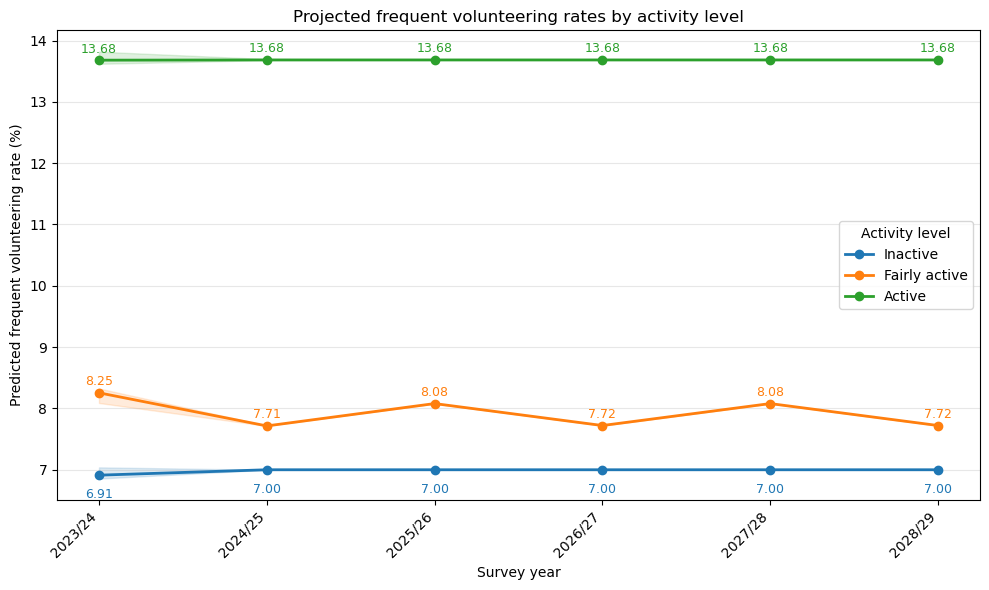

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_borough_activity_six_year_trajectories.png


In [18]:
fig, axis = plt.subplots(
    figsize=(
        10,
        6,
    )
)

label_offsets = {
    0: -14,
    1: 8,
    2: 8,
}

for activity_level in (
    ACTIVITY_ORDER
):
    plot_data = (
        borough_activity_summary.loc[
            borough_activity_summary[
                "activity_level_3cat"
            ].eq(
                activity_level
            )
        ]
        .sort_values(
            "forecast_horizon"
        )
    )

    line = axis.plot(
        plot_data[
            "forecast_horizon"
        ],
        plot_data[
            "borough_median_rate_pct"
        ],
        marker="o",
        linewidth=2,
        label=(
            ACTIVITY_DISPLAY[
                activity_level
            ]
        ),
    )[0]

    axis.fill_between(
        plot_data[
            "forecast_horizon"
        ],
        plot_data[
            "borough_q25_rate_pct"
        ],
        plot_data[
            "borough_q75_rate_pct"
        ],
        alpha=0.15,
        color=line.get_color(),
    )

    for x_value, y_value in zip(
        plot_data[
            "forecast_horizon"
        ],
        plot_data[
            "borough_median_rate_pct"
        ],
    ):
        axis.annotate(
            f"{y_value:.2f}",
            (
                x_value,
                y_value,
            ),
            xytext=(
                0,
                label_offsets[
                    activity_level
                ],
            ),
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=9,
            color=line.get_color(),
        )

axis.set_xticks(
    range(
        1,
        len(
            FUTURE_YEARS
        )
        + 1,
    )
)

axis.set_xticklabels(
    [
        CALENDAR_YEAR_LABELS[
            year
        ]
        for year in (
            FUTURE_YEARS
        )
    ],
    rotation=45,
    ha="right",
)

axis.set_xlabel(
    "Survey year"
)

axis.set_ylabel(
    "Predicted frequent volunteering rate (%)"
)

axis.set_title(
    "Projected frequent volunteering rates by activity level"
)

axis.legend(
    title="Activity level"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

activity_trajectory_path = (
    FIGURE_DIR
    / "q5_borough_activity_six_year_trajectories.png"
)

fig.savefig(
    activity_trajectory_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{activity_trajectory_path}"
)

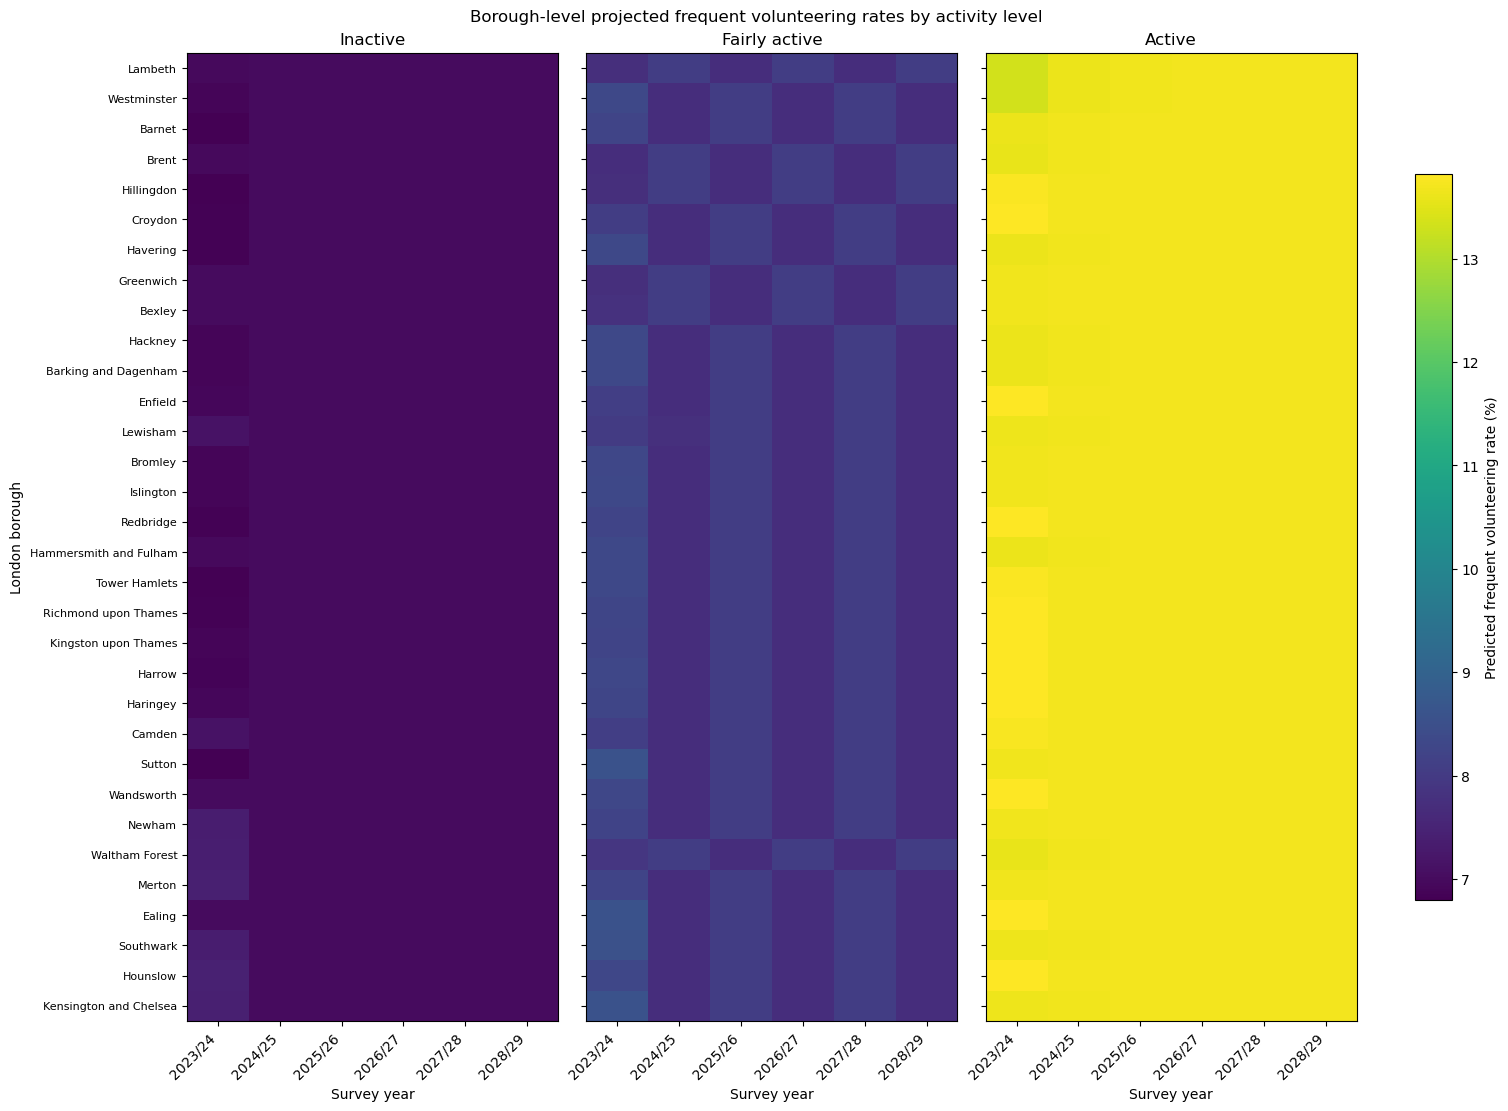

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_borough_activity_borough_heatmaps.png


In [19]:
borough_order = (
    borough_activity_future
    .groupby(
        "borough_name"
    )[
        "predicted_rate_pct"
    ]
    .mean()
    .sort_values()
    .index
    .tolist()
)

heatmap_min = (
    borough_activity_future[
        "predicted_rate_pct"
    ]
    .min()
)

heatmap_max = (
    borough_activity_future[
        "predicted_rate_pct"
    ]
    .max()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        15,
        11,
    ),
    sharey=True,
    constrained_layout=True,
)

heatmap_image = None

for axis, activity_level in zip(
    axes,
    ACTIVITY_ORDER,
):
    plot_data = (
        borough_activity_future.loc[
            borough_activity_future[
                "activity_level_3cat"
            ].eq(
                activity_level
            )
        ]
    )

    heatmap_data = (
        plot_data
        .pivot(
            index="borough_name",
            columns="year",
            values="predicted_rate_pct",
        )
        .reindex(
            borough_order
        )
        .reindex(
            columns=FUTURE_YEARS
        )
    )

    heatmap_image = axis.imshow(
        heatmap_data.to_numpy(),
        aspect="auto",
        vmin=heatmap_min,
        vmax=heatmap_max,
    )

    axis.set_title(
        ACTIVITY_DISPLAY[
            activity_level
        ]
    )

    axis.set_xlabel(
        "Survey year"
    )

    axis.set_xticks(
        range(
            len(
                FUTURE_YEARS
            )
        )
    )

    axis.set_xticklabels(
        [
            CALENDAR_YEAR_LABELS[
                year
            ]
            for year in (
                FUTURE_YEARS
            )
        ],
        rotation=45,
        ha="right",
    )

    axis.set_yticks(
        range(
            len(
                borough_order
            )
        )
    )

    axis.set_yticklabels(
        borough_order,
        fontsize=8,
    )

axes[0].set_ylabel(
    "London borough"
)

fig.suptitle(
    "Borough-level projected frequent volunteering rates by activity level"
)

fig.colorbar(
    heatmap_image,
    ax=axes,
    label=(
        "Predicted frequent volunteering rate (%)"
    ),
    shrink=0.75,
)

activity_heatmap_path = (
    FIGURE_DIR
    / "q5_borough_activity_borough_heatmaps.png"
)

fig.savefig(
    activity_heatmap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{activity_heatmap_path}"
)

### 12.2 — Borough–age projections

The borough–age forecasts are summarised for the eight age groups across all six future periods. Borough medians describe the central projected rate for each age group, while Q25–Q75 describe variation across boroughs.

In [20]:
borough_age_future = (
    future_projections_by_task[
        "borough_age"
    ]
    .copy()
)

borough_age_future[
    "calendar_year"
] = (
    borough_age_future[
        "year"
    ]
    .map(
        CALENDAR_YEAR_LABELS
    )
)

borough_age_future[
    "predicted_rate_pct"
] = (
    100
    * borough_age_future[
        "predicted_rate"
    ]
)

borough_age_future = (
    borough_age_future
    .merge(
        borough_mapping,
        on="LA_2023",
        how="left",
    )
)

borough_age_summary = (
    borough_age_future
    .groupby(
        [
            "year",
            "calendar_year",
            "forecast_horizon",
            "age_group_code",
            "age_group",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        borough_median_rate_pct=(
            "predicted_rate_pct",
            "median",
        ),
        borough_q25_rate_pct=(
            "predicted_rate_pct",
            lambda values:
                values.quantile(
                    0.25
                ),
        ),
        borough_q75_rate_pct=(
            "predicted_rate_pct",
            lambda values:
                values.quantile(
                    0.75
                ),
        ),
        equal_borough_mean_rate_pct=(
            "predicted_rate_pct",
            "mean",
        ),
    )
)

borough_age_summary = (
    borough_age_summary[
        [
            "calendar_year",
            "forecast_horizon",
            "age_group_code",
            "age_group",
            "boroughs",
            "borough_median_rate_pct",
            "borough_q25_rate_pct",
            "borough_q75_rate_pct",
            "equal_borough_mean_rate_pct",
        ]
    ]
    .sort_values(
        [
            "age_group_code",
            "forecast_horizon",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    borough_age_summary
)

age_summary_path = (
    TABLE_DIR
    / "q5_borough_age_six_year_summary.csv"
)

borough_age_summary.to_csv(
    age_summary_path,
    index=False,
)

print(
    f"Saved table: "
    f"{age_summary_path}"
)

,calendar_year,forecast_horizon,age_group_code,age_group,boroughs,borough_median_rate_pct,borough_q25_rate_pct,borough_q75_rate_pct,equal_borough_mean_rate_pct
0,2023/24,1,2,16-24,32,14.690817,14.690817,14.690817,14.733623
1,2024/25,2,2,16-24,32,14.690817,14.690817,14.690817,14.733623
2,2025/26,3,2,16-24,32,14.690817,14.690817,14.690817,14.733623
3,2026/27,4,2,16-24,32,14.690817,14.690817,14.690817,14.733623
4,2027/28,5,2,16-24,32,14.690817,14.690817,14.690817,14.733623
5,2028/29,6,2,16-24,32,14.690817,14.690817,14.690817,14.733623
6,2023/24,1,3,25-34,32,10.212178,10.212178,10.212178,10.270974
7,2024/25,2,3,25-34,32,10.212178,10.212178,10.212178,10.270974
8,2025/26,3,3,25-34,32,10.212178,10.212178,10.212178,10.270974
9,2026/27,4,3,25-34,32,10.212178,10.212178,10.212178,10.270974


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_borough_age_six_year_summary.csv


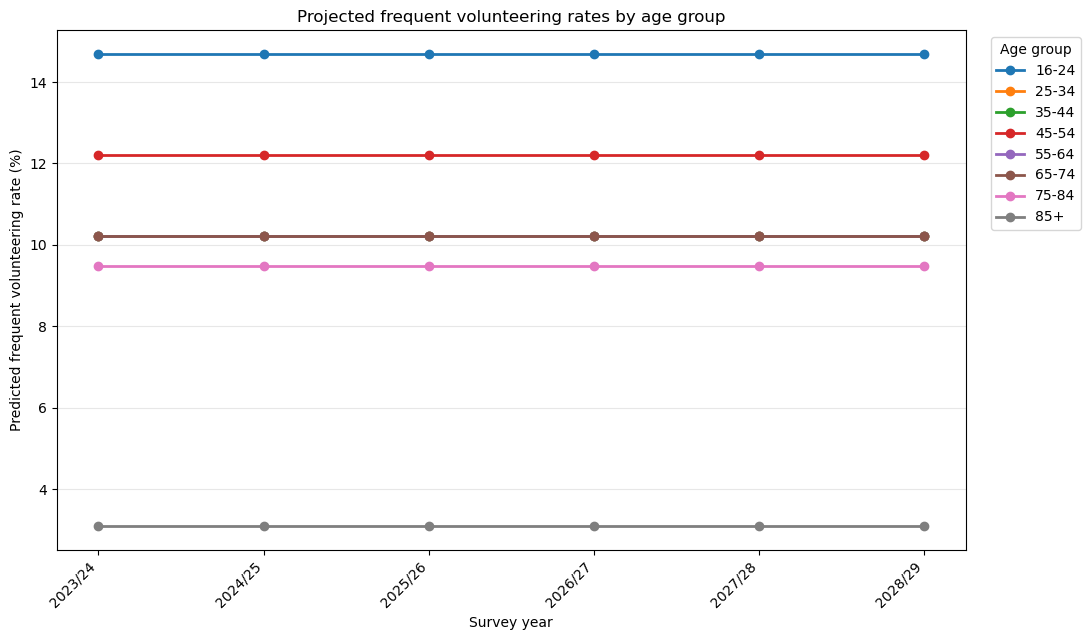

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_borough_age_six_year_trajectories.png


In [21]:
age_order = (
    borough_age_summary[
        [
            "age_group_code",
            "age_group",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "age_group_code"
    )[
        "age_group"
    ]
    .tolist()
)

fig, axis = plt.subplots(
    figsize=(
        11,
        6.5,
    )
)

for age_group in age_order:
    plot_data = (
        borough_age_summary.loc[
            borough_age_summary[
                "age_group"
            ].eq(
                age_group
            )
        ]
        .sort_values(
            "forecast_horizon"
        )
    )

    axis.plot(
        plot_data[
            "forecast_horizon"
        ],
        plot_data[
            "borough_median_rate_pct"
        ],
        marker="o",
        linewidth=2,
        label=age_group,
    )

axis.set_xticks(
    range(
        1,
        len(
            FUTURE_YEARS
        )
        + 1,
    )
)

axis.set_xticklabels(
    [
        CALENDAR_YEAR_LABELS[
            year
        ]
        for year in (
            FUTURE_YEARS
        )
    ],
    rotation=45,
    ha="right",
)

axis.set_xlabel(
    "Survey year"
)

axis.set_ylabel(
    "Predicted frequent volunteering rate (%)"
)

axis.set_title(
    "Projected frequent volunteering rates by age group"
)

axis.legend(
    title="Age group",
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)

axis.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

age_trajectory_path = (
    FIGURE_DIR
    / "q5_borough_age_six_year_trajectories.png"
)

fig.savefig(
    age_trajectory_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{age_trajectory_path}"
)

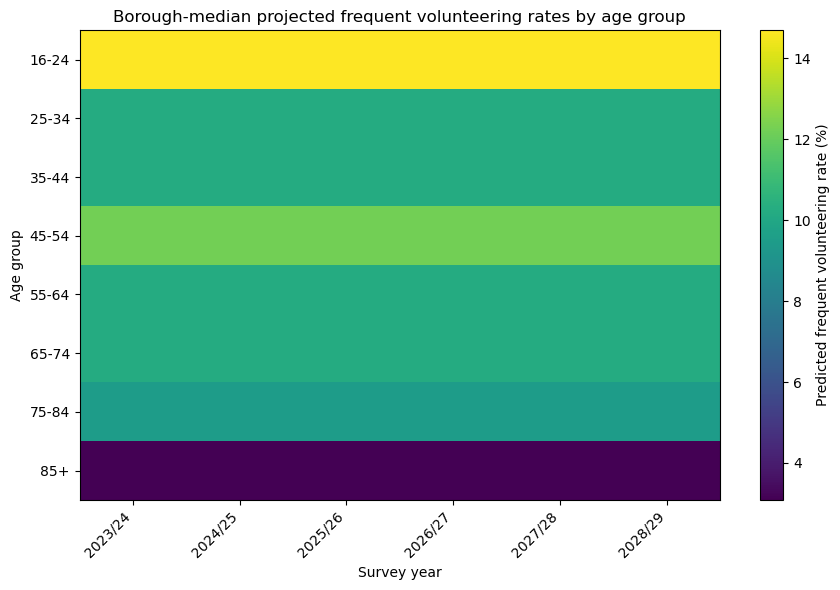

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_borough_age_age_year_heatmap.png


In [22]:
age_heatmap_data = (
    borough_age_summary
    .pivot(
        index="age_group",
        columns="forecast_horizon",
        values="borough_median_rate_pct",
    )
    .reindex(
        age_order
    )
    .reindex(
        columns=range(
            1,
            len(
                FUTURE_YEARS
            )
            + 1,
        )
    )
)

fig, axis = plt.subplots(
    figsize=(
        9,
        6,
    )
)

age_heatmap_image = axis.imshow(
    age_heatmap_data.to_numpy(),
    aspect="auto",
)

axis.set_xticks(
    range(
        len(
            FUTURE_YEARS
        )
    )
)

axis.set_xticklabels(
    [
        CALENDAR_YEAR_LABELS[
            year
        ]
        for year in (
            FUTURE_YEARS
        )
    ],
    rotation=45,
    ha="right",
)

axis.set_yticks(
    range(
        len(
            age_order
        )
    )
)

axis.set_yticklabels(
    age_order
)

axis.set_xlabel(
    "Survey year"
)

axis.set_ylabel(
    "Age group"
)

axis.set_title(
    "Borough-median projected frequent volunteering rates by age group"
)

fig.colorbar(
    age_heatmap_image,
    ax=axis,
    label=(
        "Predicted frequent volunteering rate (%)"
    ),
)

fig.tight_layout()

age_heatmap_path = (
    FIGURE_DIR
    / "q5_borough_age_age_year_heatmap.png"
)

fig.savefig(
    age_heatmap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{age_heatmap_path}"
)

## 13 — Summarise future projections by age group and activity level

The borough–age–activity projections are used to examine the joint age–activity pattern over the six forecast periods.

First, projected rates are summarised for each age group and activity level. Second, Active–Inactive and Fairly active–Inactive gaps are calculated within the same borough and age group before being summarised across boroughs.

In [23]:
borough_age_activity_future = (
    future_projections_by_task[
        "borough_age_activity"
    ]
    .copy()
)

borough_age_activity_future[
    "calendar_year"
] = (
    borough_age_activity_future[
        "year"
    ]
    .map(
        CALENDAR_YEAR_LABELS
    )
)

borough_age_activity_future[
    "predicted_rate_pct"
] = (
    100
    * borough_age_activity_future[
        "predicted_rate"
    ]
)

borough_age_activity_future = (
    borough_age_activity_future
    .merge(
        borough_mapping,
        on="LA_2023",
        how="left",
    )
)

borough_age_activity_summary = (
    borough_age_activity_future
    .groupby(
        [
            "year",
            "calendar_year",
            "forecast_horizon",
            "age_group_code",
            "age_group",
            "activity_level_3cat",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        borough_median_rate_pct=(
            "predicted_rate_pct",
            "median",
        ),
        borough_q25_rate_pct=(
            "predicted_rate_pct",
            lambda values:
                values.quantile(
                    0.25
                ),
        ),
        borough_q75_rate_pct=(
            "predicted_rate_pct",
            lambda values:
                values.quantile(
                    0.75
                ),
        ),
        equal_borough_mean_rate_pct=(
            "predicted_rate_pct",
            "mean",
        ),
    )
)

borough_age_activity_summary[
    "activity_level"
] = (
    borough_age_activity_summary[
        "activity_level_3cat"
    ]
    .map(
        ACTIVITY_DISPLAY
    )
)

borough_age_activity_summary = (
    borough_age_activity_summary[
        [
            "calendar_year",
            "forecast_horizon",
            "age_group_code",
            "age_group",
            "activity_level_3cat",
            "activity_level",
            "boroughs",
            "borough_median_rate_pct",
            "borough_q25_rate_pct",
            "borough_q75_rate_pct",
            "equal_borough_mean_rate_pct",
        ]
    ]
    .sort_values(
        [
            "age_group_code",
            "activity_level_3cat",
            "forecast_horizon",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    borough_age_activity_summary
)

baa_summary_path = (
    TABLE_DIR
    / "q5_borough_age_activity_six_year_summary.csv"
)

borough_age_activity_summary.to_csv(
    baa_summary_path,
    index=False,
)

print(
    f"Saved table: "
    f"{baa_summary_path}"
)

,calendar_year,forecast_horizon,age_group_code,age_group,activity_level_3cat,activity_level,boroughs,borough_median_rate_pct,borough_q25_rate_pct,borough_q75_rate_pct,equal_borough_mean_rate_pct
0,2023/24,1,2,16-24,0,Inactive,32,8.428199,6.593381,8.697533,7.784316
1,2024/25,2,2,16-24,0,Inactive,32,8.907150,8.907150,8.907150,8.745901
2,2025/26,3,2,16-24,0,Inactive,32,8.907150,8.907150,8.907150,8.812129
3,2026/27,4,2,16-24,0,Inactive,32,8.907150,8.907150,8.907150,8.812129
4,2027/28,5,2,16-24,0,Inactive,32,8.907150,8.907150,8.907150,8.812129
...,...,...,...,...,...,...,...,...,...,...,...
139,2024/25,2,9,85+,2,Active,32,4.543646,3.617466,4.609797,4.476962
140,2025/26,3,9,85+,2,Active,32,5.857357,4.543646,5.857357,5.258759
141,2026/27,4,9,85+,2,Active,32,5.857357,5.857357,5.857357,5.587187
142,2027/28,5,9,85+,2,Active,32,5.857357,5.857357,5.857357,5.587187


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_borough_age_activity_six_year_summary.csv


### 13.1 — Age-specific activity-level trajectories

The trajectories compare the three activity levels separately within each age group. Borough medians are shown as the main projected rates, with Q25–Q75 indicating variation across London boroughs.

A common vertical scale is used across all age-group panels so that projected rate levels can be compared directly.

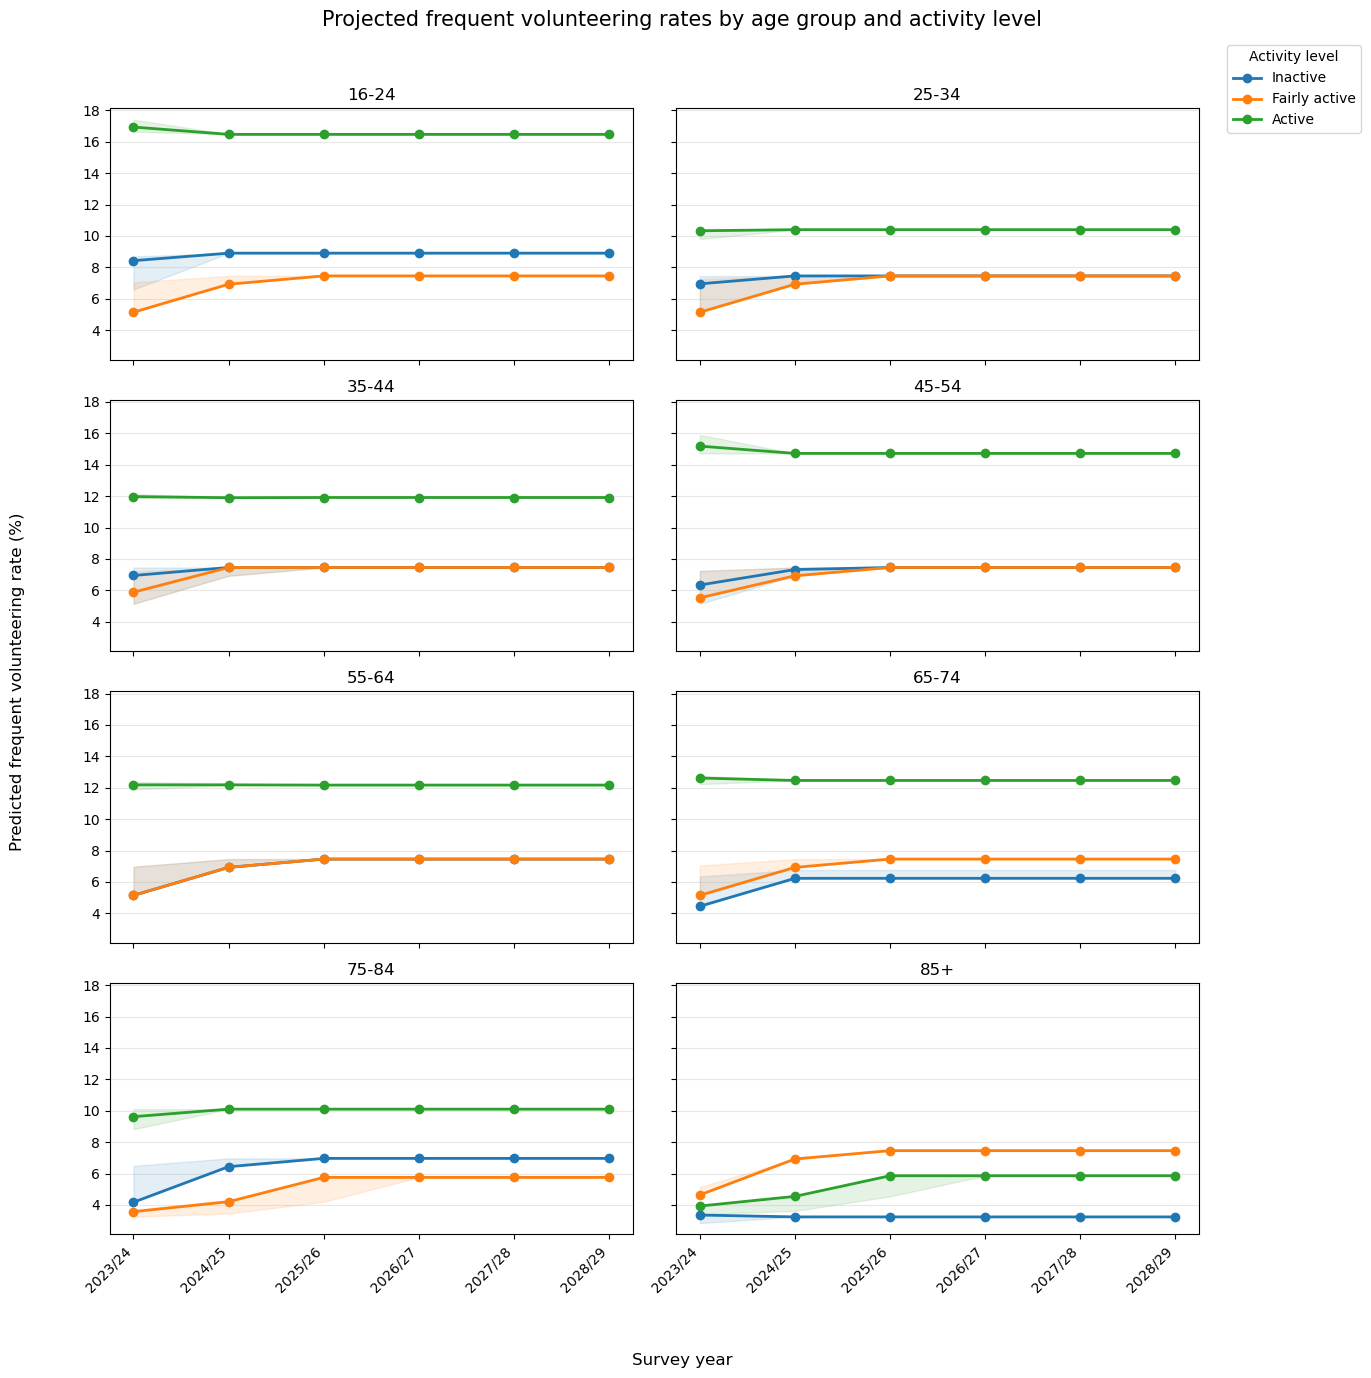

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_borough_age_activity_six_year_trajectories.png


In [24]:
baa_age_order = (
    borough_age_activity_summary[
        [
            "age_group_code",
            "age_group",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "age_group_code"
    )[
        "age_group"
    ]
    .tolist()
)

activity_colours = {
    activity_level: colour
    for activity_level, colour in zip(
        ACTIVITY_ORDER,
        plt.rcParams[
            "axes.prop_cycle"
        ]
        .by_key()[
            "color"
        ],
    )
}

fig, axes = plt.subplots(
    4,
    2,
    figsize=(
        14,
        14,
    ),
    sharex=True,
    sharey=True,
)

axes_flat = (
    axes
    .flatten()
)

for axis, age_group in zip(
    axes_flat,
    baa_age_order,
):
    age_data = (
        borough_age_activity_summary.loc[
            borough_age_activity_summary[
                "age_group"
            ].eq(
                age_group
            )
        ]
    )

    for activity_level in (
        ACTIVITY_ORDER
    ):
        plot_data = (
            age_data.loc[
                age_data[
                    "activity_level_3cat"
                ].eq(
                    activity_level
                )
            ]
            .sort_values(
                "forecast_horizon"
            )
        )

        axis.plot(
            plot_data[
                "forecast_horizon"
            ],
            plot_data[
                "borough_median_rate_pct"
            ],
            marker="o",
            linewidth=2,
            color=(
                activity_colours[
                    activity_level
                ]
            ),
            label=(
                ACTIVITY_DISPLAY[
                    activity_level
                ]
            ),
        )

        axis.fill_between(
            plot_data[
                "forecast_horizon"
            ],
            plot_data[
                "borough_q25_rate_pct"
            ],
            plot_data[
                "borough_q75_rate_pct"
            ],
            alpha=0.12,
            color=(
                activity_colours[
                    activity_level
                ]
            ),
        )

    axis.set_title(
        age_group
    )

    axis.set_xticks(
        range(
            1,
            len(
                FUTURE_YEARS
            )
            + 1,
        )
    )

    axis.set_xticklabels(
        [
            CALENDAR_YEAR_LABELS[
                year
            ]
            for year in (
                FUTURE_YEARS
            )
        ],
        rotation=45,
        ha="right",
    )

    axis.grid(
        axis="y",
        alpha=0.3,
    )

handles, labels = (
    axes_flat[
        0
    ]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    title="Activity level",
    bbox_to_anchor=(
        0.99,
        0.96,
    ),
    loc="upper right",
)

fig.supxlabel(
    "Survey year"
)

fig.supylabel(
    "Predicted frequent volunteering rate (%)"
)

fig.suptitle(
    "Projected frequent volunteering rates by age group and activity level",
    fontsize=15,
)

fig.tight_layout(
    rect=(
        0.03,
        0.03,
        0.88,
        0.96,
    )
)

baa_trajectory_path = (
    FIGURE_DIR
    / "q5_borough_age_activity_six_year_trajectories.png"
)

fig.savefig(
    baa_trajectory_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{baa_trajectory_path}"
)

### 13.2 — Age-specific activity-level gaps

Activity-level gaps are calculated within the same borough, age group and forecast period.

Two comparisons are examined:

- Active minus Inactive;
- Fairly active minus Inactive.

The resulting borough-level gaps are expressed in percentage points and then summarised across boroughs for each age group and forecast period.

In [25]:
baa_gap_wide = (
    borough_age_activity_future
    .pivot(
        index=[
            "year",
            "calendar_year",
            "forecast_horizon",
            "LA_2023",
            "borough_name",
            "age_group_code",
            "age_group",
        ],
        columns="activity_level_3cat",
        values="predicted_rate_pct",
    )
    .reset_index()
)

baa_active_inactive = (
    baa_gap_wide[
        [
            "year",
            "calendar_year",
            "forecast_horizon",
            "LA_2023",
            "borough_name",
            "age_group_code",
            "age_group",
        ]
    ]
    .copy()
)

baa_active_inactive[
    "comparison"
] = (
    "Active - Inactive"
)

baa_active_inactive[
    "gap_pp"
] = (
    baa_gap_wide[
        2
    ]
    - baa_gap_wide[
        0
    ]
)

baa_fairly_inactive = (
    baa_gap_wide[
        [
            "year",
            "calendar_year",
            "forecast_horizon",
            "LA_2023",
            "borough_name",
            "age_group_code",
            "age_group",
        ]
    ]
    .copy()
)

baa_fairly_inactive[
    "comparison"
] = (
    "Fairly active - Inactive"
)

baa_fairly_inactive[
    "gap_pp"
] = (
    baa_gap_wide[
        1
    ]
    - baa_gap_wide[
        0
    ]
)

borough_age_activity_gaps = (
    pd.concat(
        [
            baa_active_inactive,
            baa_fairly_inactive,
        ],
        ignore_index=True,
    )
)

GAP_ORDER = {
    "Active - Inactive": 0,
    "Fairly active - Inactive": 1,
}

borough_age_activity_gap_summary = (
    borough_age_activity_gaps
    .groupby(
        [
            "year",
            "calendar_year",
            "forecast_horizon",
            "age_group_code",
            "age_group",
            "comparison",
        ],
        as_index=False,
    )
    .agg(
        boroughs=(
            "LA_2023",
            "nunique",
        ),
        median_gap_pp=(
            "gap_pp",
            "median",
        ),
        q25_gap_pp=(
            "gap_pp",
            lambda values:
                values.quantile(
                    0.25
                ),
        ),
        q75_gap_pp=(
            "gap_pp",
            lambda values:
                values.quantile(
                    0.75
                ),
        ),
    )
)

borough_age_activity_gap_summary[
    "comparison_order"
] = (
    borough_age_activity_gap_summary[
        "comparison"
    ]
    .map(
        GAP_ORDER
    )
)

borough_age_activity_gap_summary = (
    borough_age_activity_gap_summary
    .sort_values(
        [
            "comparison_order",
            "age_group_code",
            "forecast_horizon",
        ]
    )
    .drop(
        columns=[
            "year",
            "comparison_order",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    borough_age_activity_gap_summary
)

baa_gap_summary_path = (
    TABLE_DIR
    / "q5_borough_age_activity_gap_summary.csv"
)

borough_age_activity_gap_summary.to_csv(
    baa_gap_summary_path,
    index=False,
)

print(
    f"Saved table: "
    f"{baa_gap_summary_path}"
)

,calendar_year,forecast_horizon,age_group_code,age_group,comparison,boroughs,median_gap_pp,q25_gap_pp,q75_gap_pp
0,2023/24,1,2,16-24,Active - Inactive,32,8.961886,8.073740,10.219820
1,2024/25,2,2,16-24,Active - Inactive,32,7.566956,7.566956,7.919554
2,2025/26,3,2,16-24,Active - Inactive,32,7.566956,7.566956,7.566956
3,2026/27,4,2,16-24,Active - Inactive,32,7.566956,7.566956,7.566956
4,2027/28,5,2,16-24,Active - Inactive,32,7.566956,7.566956,7.566956
...,...,...,...,...,...,...,...,...,...
91,2024/25,2,9,85+,Fairly active - Inactive,32,3.690611,3.665215,3.690611
92,2025/26,3,9,85+,Fairly active - Inactive,32,4.220439,3.714465,4.220439
93,2026/27,4,9,85+,Fairly active - Inactive,32,4.220439,3.714465,4.220439
94,2027/28,5,9,85+,Fairly active - Inactive,32,4.220439,3.714465,4.220439


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_borough_age_activity_gap_summary.csv


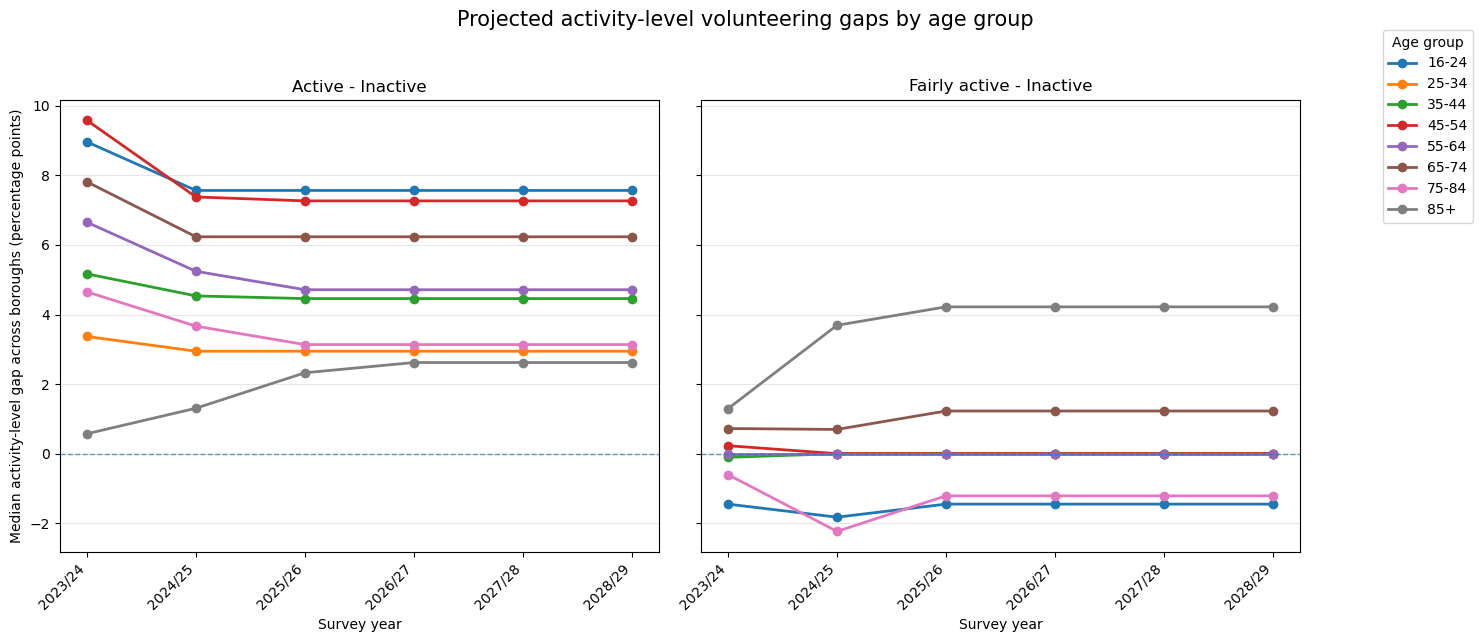

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_borough_age_activity_gap_trajectories.png


In [26]:
gap_comparisons = [
    "Active - Inactive",
    "Fairly active - Inactive",
]

age_colours = {
    age_group: colour
    for age_group, colour in zip(
        baa_age_order,
        plt.rcParams[
            "axes.prop_cycle"
        ]
        .by_key()[
            "color"
        ],
    )
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        15,
        6.5,
    ),
    sharex=True,
    sharey=True,
)

for axis, comparison in zip(
    axes,
    gap_comparisons,
):
    comparison_data = (
        borough_age_activity_gap_summary.loc[
            borough_age_activity_gap_summary[
                "comparison"
            ].eq(
                comparison
            )
        ]
    )

    for age_group in (
        baa_age_order
    ):
        plot_data = (
            comparison_data.loc[
                comparison_data[
                    "age_group"
                ].eq(
                    age_group
                )
            ]
            .sort_values(
                "forecast_horizon"
            )
        )

        axis.plot(
            plot_data[
                "forecast_horizon"
            ],
            plot_data[
                "median_gap_pp"
            ],
            marker="o",
            linewidth=2,
            color=(
                age_colours[
                    age_group
                ]
            ),
            label=age_group,
        )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    axis.set_title(
        comparison
    )

    axis.set_xticks(
        range(
            1,
            len(
                FUTURE_YEARS
            )
            + 1,
        )
    )

    axis.set_xticklabels(
        [
            CALENDAR_YEAR_LABELS[
                year
            ]
            for year in (
                FUTURE_YEARS
            )
        ],
        rotation=45,
        ha="right",
    )

    axis.set_xlabel(
        "Survey year"
    )

    axis.grid(
        axis="y",
        alpha=0.3,
    )

axes[
    0
].set_ylabel(
    "Median activity-level gap across boroughs (percentage points)"
)

handles, labels = (
    axes[
        0
    ]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    title="Age group",
    bbox_to_anchor=(
        0.99,
        0.96,
    ),
    loc="upper right",
)

fig.suptitle(
    "Projected activity-level volunteering gaps by age group",
    fontsize=15,
)

fig.tight_layout(
    rect=(
        0,
        0,
        0.88,
        0.95,
    )
)

baa_gap_trajectory_path = (
    FIGURE_DIR
    / "q5_borough_age_activity_gap_trajectories.png"
)

fig.savefig(
    baa_gap_trajectory_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{baa_gap_trajectory_path}"
)

## 14 — Compare historical and forecast subgroup patterns

This module compares the six historical survey periods (2017/18–2022/23) with the six forecast periods (2023/24–2028/29).

The comparison focuses on three subgroup patterns:

1. activity-level ordering;
2. age-group profile;
3. age-specific activity-level gaps.

For each subgroup, each six-year period is represented by the median of its six annual borough-median estimates. The resulting comparisons are descriptive summaries of subgroup-pattern continuity rather than observed historical-to-future changes.

In [27]:
HISTORICAL_OUTPUT_DIR = (
    PROJECT_DIR
    / "q4_historical_outputs"
)

HISTORICAL_TABLE_DIR = (
    HISTORICAL_OUTPUT_DIR
    / "descriptive_tables"
)

historical_activity = pd.read_csv(
    HISTORICAL_TABLE_DIR
    / "q5_historical_activity_median.csv"
)

historical_age = pd.read_csv(
    HISTORICAL_TABLE_DIR
    / "q5_historical_age_median.csv"
)

historical_gap = pd.read_csv(
    HISTORICAL_TABLE_DIR
    / "q5_historical_gap_by_age_year.csv"
)

historical_activity[
    "median_borough_rate_pct"
] = (
    100
    * historical_activity[
        "median_borough_rate"
    ]
)

historical_age[
    "median_borough_rate_pct"
] = (
    100
    * historical_age[
        "median_borough_rate"
    ]
)

HISTORICAL_ACTIVITY_DISPLAY = {
    "inactive": "Inactive",
    "fairly_active": "Fairly active",
    "active": "Active",
}

historical_activity[
    "activity_level"
] = (
    historical_activity[
        "activity_level_3cat_label"
    ]
    .map(
        HISTORICAL_ACTIVITY_DISPLAY
    )
)

COMPARISON_ACTIVITY_ORDER = [
    "Inactive",
    "Fairly active",
    "Active",
]

COMPARISON_AGE_ORDER = (
    borough_age_summary[
        [
            "age_group_code",
            "age_group",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "age_group_code"
    )[
        "age_group"
    ]
    .tolist()
)

### 14.1 — Historical and forecast activity-level ordering

The activity-level comparison examines whether the relative volunteering-rate pattern observed historically is retained in the forecast period.

For each activity level, the historical and forecast values are the medians of the six annual borough-median rates within their respective periods.

In [28]:
historical_activity_period = (
    historical_activity
    .groupby(
        "activity_level",
        as_index=False,
    )
    .agg(
        historical_period_median_rate_pct=(
            "median_borough_rate_pct",
            "median",
        ),
        historical_years=(
            "year",
            "nunique",
        ),
    )
)

forecast_activity_period = (
    borough_activity_summary
    .groupby(
        "activity_level",
        as_index=False,
    )
    .agg(
        forecast_period_median_rate_pct=(
            "borough_median_rate_pct",
            "median",
        ),
        forecast_years=(
            "forecast_horizon",
            "nunique",
        ),
    )
)

activity_historical_forecast_comparison = (
    historical_activity_period
    .merge(
        forecast_activity_period,
        on="activity_level",
        how="inner",
    )
)

activity_historical_forecast_comparison[
    "period_difference_pp"
] = (
    activity_historical_forecast_comparison[
        "forecast_period_median_rate_pct"
    ]
    - activity_historical_forecast_comparison[
        "historical_period_median_rate_pct"
    ]
)

activity_historical_forecast_comparison[
    "historical_rank"
] = (
    activity_historical_forecast_comparison[
        "historical_period_median_rate_pct"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

activity_historical_forecast_comparison[
    "forecast_rank"
] = (
    activity_historical_forecast_comparison[
        "forecast_period_median_rate_pct"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

activity_historical_forecast_comparison[
    "activity_order"
] = (
    activity_historical_forecast_comparison[
        "activity_level"
    ]
    .map(
        {
            activity_level: order
            for order, activity_level in enumerate(
                COMPARISON_ACTIVITY_ORDER
            )
        }
    )
)

activity_historical_forecast_comparison = (
    activity_historical_forecast_comparison
    .sort_values(
        "activity_order"
    )
    .drop(
        columns=[
            "activity_order",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    activity_historical_forecast_comparison
)

activity_comparison_path = (
    TABLE_DIR
    / "q5_historical_forecast_activity_comparison.csv"
)

activity_historical_forecast_comparison.to_csv(
    activity_comparison_path,
    index=False,
)

print(
    f"Saved table: "
    f"{activity_comparison_path}"
)

,activity_level,historical_period_median_rate_pct,historical_years,forecast_period_median_rate_pct,forecast_years,period_difference_pp,historical_rank,forecast_rank
0,Inactive,4.891425,6,6.998979,6,2.107554,3,3
1,Fairly active,6.946918,6,7.899520,6,0.952602,2,2
2,Active,13.056820,6,13.683538,6,0.626718,1,1


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_historical_forecast_activity_comparison.csv


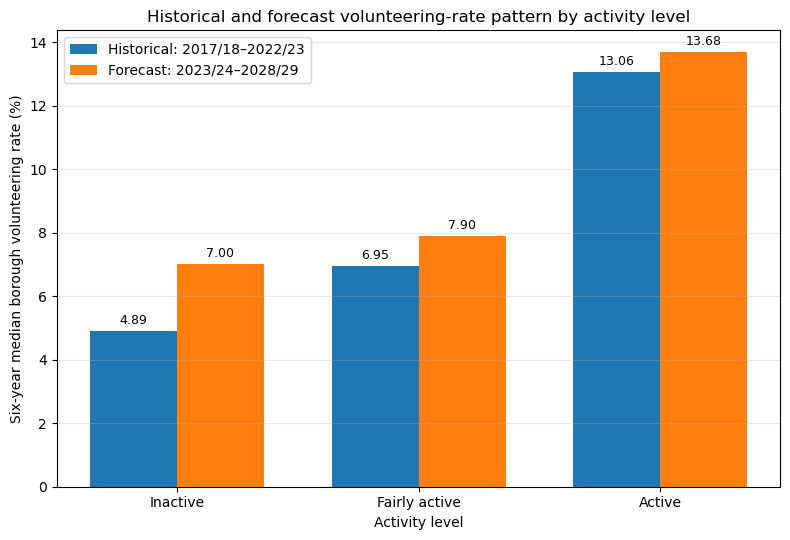

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_historical_forecast_activity_comparison.png


In [29]:
activity_plot_data = (
    activity_historical_forecast_comparison
    .set_index(
        "activity_level"
    )
    .reindex(
        COMPARISON_ACTIVITY_ORDER
    )
    .reset_index()
)

x_positions = np.arange(
    len(
        COMPARISON_ACTIVITY_ORDER
    )
)

bar_width = 0.36

fig, axis = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)

historical_bars = axis.bar(
    x_positions
    - bar_width / 2,
    activity_plot_data[
        "historical_period_median_rate_pct"
    ],
    width=bar_width,
    label="Historical: 2017/18–2022/23",
)

forecast_bars = axis.bar(
    x_positions
    + bar_width / 2,
    activity_plot_data[
        "forecast_period_median_rate_pct"
    ],
    width=bar_width,
    label="Forecast: 2023/24–2028/29",
)

axis.bar_label(
    historical_bars,
    fmt="%.2f",
    padding=3,
    fontsize=9,
)

axis.bar_label(
    forecast_bars,
    fmt="%.2f",
    padding=3,
    fontsize=9,
)

axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    COMPARISON_ACTIVITY_ORDER
)

axis.set_xlabel(
    "Activity level"
)

axis.set_ylabel(
    "Six-year median borough volunteering rate (%)"
)

axis.set_title(
    "Historical and forecast volunteering-rate pattern by activity level"
)

axis.legend()

axis.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

activity_comparison_figure_path = (
    FIGURE_DIR
    / "q5_historical_forecast_activity_comparison.png"
)

fig.savefig(
    activity_comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{activity_comparison_figure_path}"
)

### 14.2 — Historical and forecast age-group profiles

The age-group comparison examines whether the broad age-related pattern in frequent volunteering is retained in the forecast period.

The comparison focuses on relative subgroup levels and rankings rather than interpreting the difference between the two period summaries as a directly observed temporal change.

In [30]:
historical_age_period = (
    historical_age
    .groupby(
        [
            "age_group_code",
            "age_group",
        ],
        as_index=False,
    )
    .agg(
        historical_period_median_rate_pct=(
            "median_borough_rate_pct",
            "median",
        ),
        historical_years=(
            "year",
            "nunique",
        ),
    )
)

forecast_age_period = (
    borough_age_summary
    .groupby(
        [
            "age_group_code",
            "age_group",
        ],
        as_index=False,
    )
    .agg(
        forecast_period_median_rate_pct=(
            "borough_median_rate_pct",
            "median",
        ),
        forecast_years=(
            "forecast_horizon",
            "nunique",
        ),
    )
)

age_historical_forecast_comparison = (
    historical_age_period
    .merge(
        forecast_age_period,
        on=[
            "age_group_code",
            "age_group",
        ],
        how="inner",
    )
)

age_historical_forecast_comparison[
    "period_difference_pp"
] = (
    age_historical_forecast_comparison[
        "forecast_period_median_rate_pct"
    ]
    - age_historical_forecast_comparison[
        "historical_period_median_rate_pct"
    ]
)

age_historical_forecast_comparison[
    "historical_rank"
] = (
    age_historical_forecast_comparison[
        "historical_period_median_rate_pct"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

age_historical_forecast_comparison[
    "forecast_rank"
] = (
    age_historical_forecast_comparison[
        "forecast_period_median_rate_pct"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

age_historical_forecast_comparison = (
    age_historical_forecast_comparison
    .sort_values(
        "age_group_code"
    )
    .reset_index(
        drop=True
    )
)

display(
    age_historical_forecast_comparison
)

age_comparison_path = (
    TABLE_DIR
    / "q5_historical_forecast_age_comparison.csv"
)

age_historical_forecast_comparison.to_csv(
    age_comparison_path,
    index=False,
)

print(
    f"Saved table: "
    f"{age_comparison_path}"
)

,age_group_code,age_group,historical_period_median_rate_pct,historical_years,forecast_period_median_rate_pct,forecast_years,period_difference_pp,historical_rank,forecast_rank
0,2,16-24,14.260504,6,14.690817,6,0.430312,1,1
1,3,25-34,8.202404,6,10.212178,6,2.009774,6,3
2,4,35-44,9.520383,6,10.212178,6,0.691795,3,3
3,5,45-54,12.400438,6,12.215765,6,-0.184674,2,2
4,6,55-64,9.171834,6,10.212178,6,1.040344,4,3
5,7,65-74,8.903690,6,10.212178,6,1.308489,5,3
6,8,75-84,6.938711,6,9.488685,6,2.549973,7,7
7,9,85+,0.000000,6,3.088180,6,3.088180,8,8


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_historical_forecast_age_comparison.csv


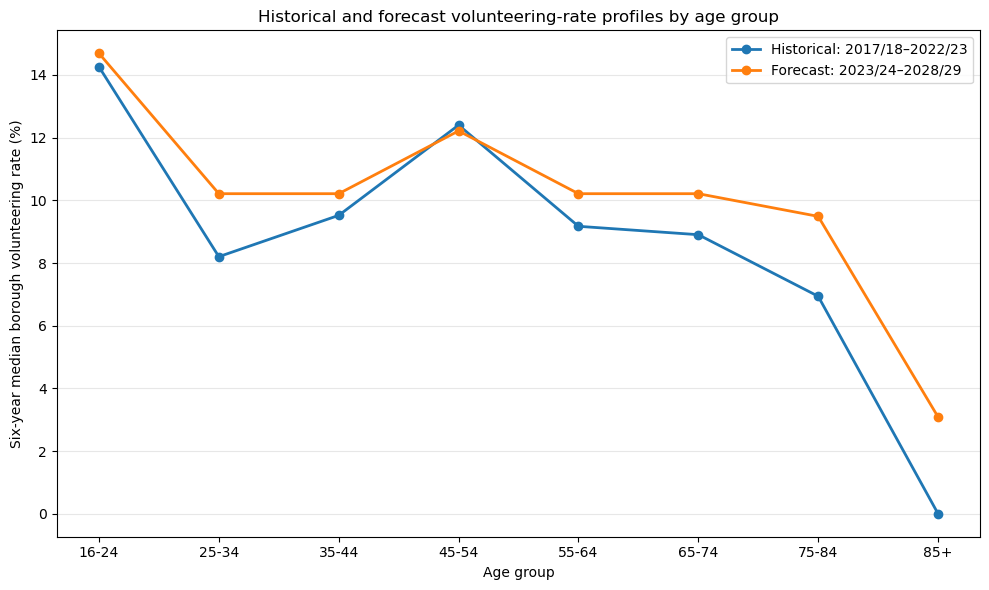

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_historical_forecast_age_profile.png


In [31]:
age_plot_data = (
    age_historical_forecast_comparison
    .set_index(
        "age_group"
    )
    .reindex(
        COMPARISON_AGE_ORDER
    )
    .reset_index()
)

x_positions = np.arange(
    len(
        COMPARISON_AGE_ORDER
    )
)

fig, axis = plt.subplots(
    figsize=(
        10,
        6,
    )
)

axis.plot(
    x_positions,
    age_plot_data[
        "historical_period_median_rate_pct"
    ],
    marker="o",
    linewidth=2,
    label="Historical: 2017/18–2022/23",
)

axis.plot(
    x_positions,
    age_plot_data[
        "forecast_period_median_rate_pct"
    ],
    marker="o",
    linewidth=2,
    label="Forecast: 2023/24–2028/29",
)

axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    COMPARISON_AGE_ORDER
)

axis.set_xlabel(
    "Age group"
)

axis.set_ylabel(
    "Six-year median borough volunteering rate (%)"
)

axis.set_title(
    "Historical and forecast volunteering-rate profiles by age group"
)

axis.legend()

axis.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

age_comparison_figure_path = (
    FIGURE_DIR
    / "q5_historical_forecast_age_profile.png"
)

fig.savefig(
    age_comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{age_comparison_figure_path}"
)

### 14.3 — Historical and forecast age-specific activity-level gaps

The final comparison examines whether the age pattern of activity-level volunteering gaps observed historically is also present in the forecast period.

Active–Inactive and Fairly active–Inactive gaps are compared separately. Historical and forecast values are based on within-borough activity-level contrasts and are therefore directly comparable at the same age-specific borough level.

In [32]:
historical_active_gap = (
    historical_gap[
        [
            "year",
            "age_group_code",
            "age_group",
            "median_active_inactive_gap",
            "boroughs_with_active_inactive_gap",
        ]
    ]
    .rename(
        columns={
            "median_active_inactive_gap":
                "median_gap",
            "boroughs_with_active_inactive_gap":
                "boroughs",
        }
    )
    .copy()
)

historical_active_gap[
    "comparison"
] = (
    "Active - Inactive"
)

historical_fairly_gap = (
    historical_gap[
        [
            "year",
            "age_group_code",
            "age_group",
            "median_fairly_inactive_gap",
            "boroughs_with_fairly_inactive_gap",
        ]
    ]
    .rename(
        columns={
            "median_fairly_inactive_gap":
                "median_gap",
            "boroughs_with_fairly_inactive_gap":
                "boroughs",
        }
    )
    .copy()
)

historical_fairly_gap[
    "comparison"
] = (
    "Fairly active - Inactive"
)

historical_gap_long = (
    pd.concat(
        [
            historical_active_gap,
            historical_fairly_gap,
        ],
        ignore_index=True,
    )
)

historical_gap_long[
    "median_gap_pp"
] = (
    100
    * historical_gap_long[
        "median_gap"
    ]
)

historical_gap_period = (
    historical_gap_long
    .groupby(
        [
            "age_group_code",
            "age_group",
            "comparison",
        ],
        as_index=False,
    )
    .agg(
        historical_period_median_gap_pp=(
            "median_gap_pp",
            "median",
        ),
        historical_years=(
            "year",
            "nunique",
        ),
        historical_median_boroughs=(
            "boroughs",
            "median",
        ),
    )
)

forecast_gap_period = (
    borough_age_activity_gap_summary
    .groupby(
        [
            "age_group_code",
            "age_group",
            "comparison",
        ],
        as_index=False,
    )
    .agg(
        forecast_period_median_gap_pp=(
            "median_gap_pp",
            "median",
        ),
        forecast_years=(
            "forecast_horizon",
            "nunique",
        ),
        forecast_median_boroughs=(
            "boroughs",
            "median",
        ),
    )
)

gap_historical_forecast_comparison = (
    historical_gap_period
    .merge(
        forecast_gap_period,
        on=[
            "age_group_code",
            "age_group",
            "comparison",
        ],
        how="inner",
    )
)

gap_historical_forecast_comparison[
    "period_difference_pp"
] = (
    gap_historical_forecast_comparison[
        "forecast_period_median_gap_pp"
    ]
    - gap_historical_forecast_comparison[
        "historical_period_median_gap_pp"
    ]
)

gap_historical_forecast_comparison[
    "comparison_order"
] = (
    gap_historical_forecast_comparison[
        "comparison"
    ]
    .map(
        {
            "Active - Inactive": 0,
            "Fairly active - Inactive": 1,
        }
    )
)

gap_historical_forecast_comparison = (
    gap_historical_forecast_comparison
    .sort_values(
        [
            "comparison_order",
            "age_group_code",
        ]
    )
    .drop(
        columns=[
            "comparison_order",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    gap_historical_forecast_comparison
)

gap_comparison_path = (
    TABLE_DIR
    / "q5_historical_forecast_age_activity_gap_comparison.csv"
)

gap_historical_forecast_comparison.to_csv(
    gap_comparison_path,
    index=False,
)

print(
    f"Saved table: "
    f"{gap_comparison_path}"
)

,age_group_code,age_group,comparison,historical_period_median_gap_pp,historical_years,historical_median_boroughs,forecast_period_median_gap_pp,forecast_years,forecast_median_boroughs,period_difference_pp
0,2,16-24,Active - Inactive,10.249552,6,31.5,7.566956,6,32.0,-2.682596
1,3,25-34,Active - Inactive,6.418039,6,32.0,2.945572,6,32.0,-3.472467
2,4,35-44,Active - Inactive,6.712642,6,32.0,4.458338,6,32.0,-2.254304
3,5,45-54,Active - Inactive,10.318780,6,32.0,7.267085,6,32.0,-3.051695
4,6,55-64,Active - Inactive,8.005374,6,32.0,4.712852,6,32.0,-3.292521
5,7,65-74,Active - Inactive,9.886735,6,32.0,6.234637,6,32.0,-3.652098
6,8,75-84,Active - Inactive,7.721059,6,31.0,3.136025,6,32.0,-4.585034
7,9,85+,Active - Inactive,0.000000,6,15.5,2.473108,6,32.0,2.473108
8,2,16-24,Fairly active - Inactive,0.000000,6,30.0,-1.449794,6,32.0,-1.449794
9,3,25-34,Fairly active - Inactive,0.000000,6,32.0,0.000000,6,32.0,0.000000


Saved table: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/tables/q5_historical_forecast_age_activity_gap_comparison.csv


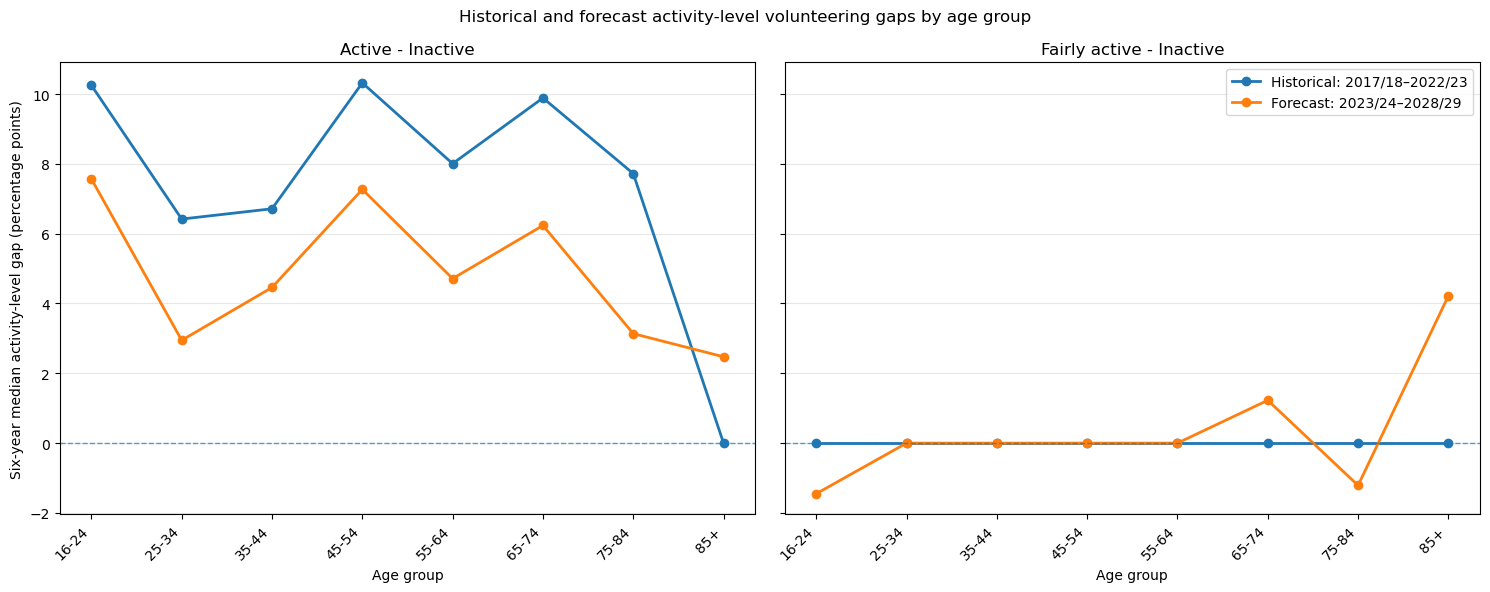

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_historical_forecast_age_activity_gap_profile.png


In [33]:
gap_comparisons = [
    "Active - Inactive",
    "Fairly active - Inactive",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        15,
        6,
    ),
    sharex=True,
    sharey=True,
)

x_positions = np.arange(
    len(
        COMPARISON_AGE_ORDER
    )
)

for axis, comparison in zip(
    axes,
    gap_comparisons,
):
    plot_data = (
        gap_historical_forecast_comparison.loc[
            gap_historical_forecast_comparison[
                "comparison"
            ].eq(
                comparison
            )
        ]
        .set_index(
            "age_group"
        )
        .reindex(
            COMPARISON_AGE_ORDER
        )
        .reset_index()
    )

    axis.plot(
        x_positions,
        plot_data[
            "historical_period_median_gap_pp"
        ],
        marker="o",
        linewidth=2,
        label="Historical: 2017/18–2022/23",
    )

    axis.plot(
        x_positions,
        plot_data[
            "forecast_period_median_gap_pp"
        ],
        marker="o",
        linewidth=2,
        label="Forecast: 2023/24–2028/29",
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    axis.set_xticks(
        x_positions
    )

    axis.set_xticklabels(
        COMPARISON_AGE_ORDER,
        rotation=45,
        ha="right",
    )

    axis.set_xlabel(
        "Age group"
    )

    axis.set_title(
        comparison
    )

    axis.grid(
        axis="y",
        alpha=0.3,
    )

axes[
    0
].set_ylabel(
    "Six-year median activity-level gap (percentage points)"
)

axes[
    1
].legend()

fig.suptitle(
    "Historical and forecast activity-level volunteering gaps by age group"
)

fig.tight_layout()

gap_comparison_figure_path = (
    FIGURE_DIR
    / "q5_historical_forecast_age_activity_gap_profile.png"
)

fig.savefig(
    gap_comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{gap_comparison_figure_path}"
)

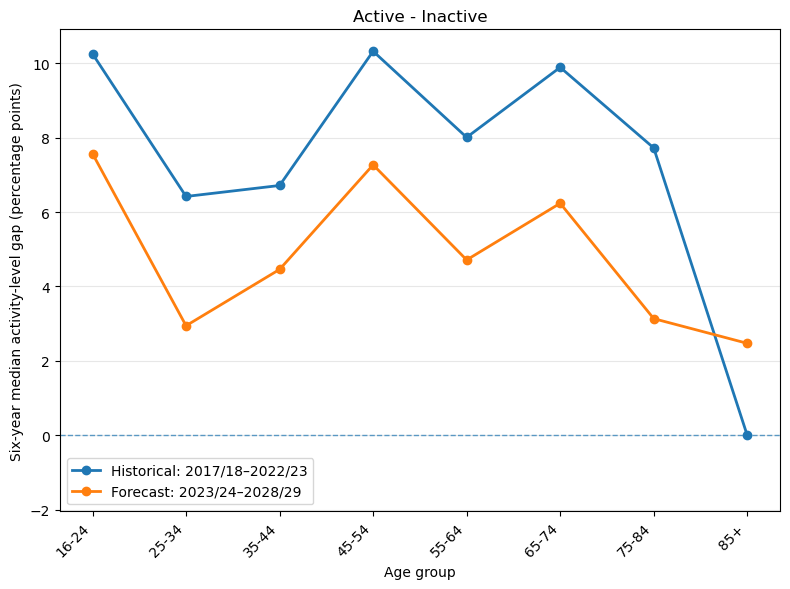

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_historical_forecast_active_inactive_gap_profile.png


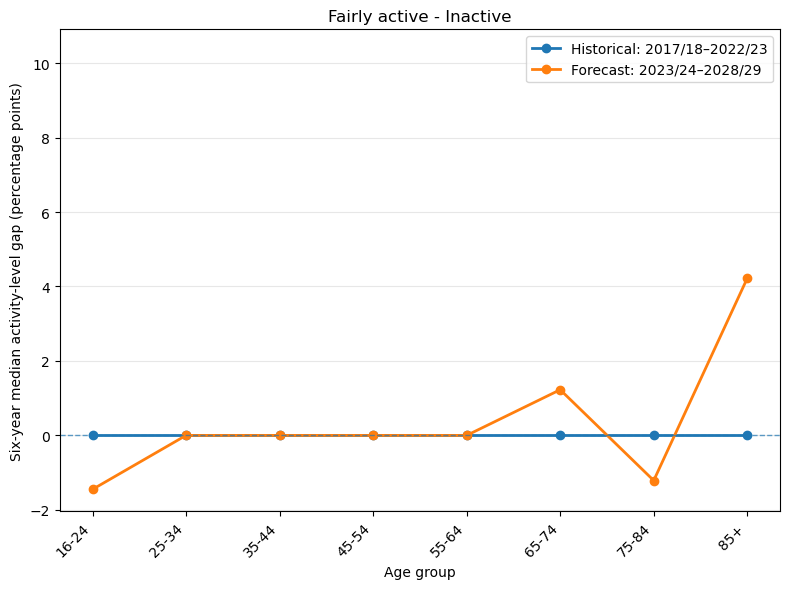

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_future_forecasting_outputs/figures/q5_historical_forecast_fairly_active_inactive_gap_profile.png


In [35]:
gap_comparisons = [
    "Active - Inactive",
    "Fairly active - Inactive",
]

gap_figure_names = {
    "Active - Inactive": (
        "q5_historical_forecast_active_inactive_gap_profile.png"
    ),
    "Fairly active - Inactive": (
        "q5_historical_forecast_fairly_active_inactive_gap_profile.png"
    ),
}

x_positions = np.arange(
    len(
        COMPARISON_AGE_ORDER
    )
)

gap_value_columns = [
    "historical_period_median_gap_pp",
    "forecast_period_median_gap_pp",
]

gap_plot_min = min(
    0,
    gap_historical_forecast_comparison[
        gap_value_columns
    ]
    .min()
    .min(),
)

gap_plot_max = max(
    0,
    gap_historical_forecast_comparison[
        gap_value_columns
    ]
    .max()
    .max(),
)

gap_plot_range = (
    gap_plot_max
    - gap_plot_min
)

gap_plot_padding = (
    0.05
    * gap_plot_range
)

gap_y_limits = (
    gap_plot_min
    - gap_plot_padding,
    gap_plot_max
    + gap_plot_padding,
)

for comparison in (
    gap_comparisons
):
    plot_data = (
        gap_historical_forecast_comparison.loc[
            gap_historical_forecast_comparison[
                "comparison"
            ].eq(
                comparison
            )
        ]
        .set_index(
            "age_group"
        )
        .reindex(
            COMPARISON_AGE_ORDER
        )
        .reset_index()
    )

    fig, axis = plt.subplots(
        figsize=(
            8,
            6,
        )
    )

    axis.plot(
        x_positions,
        plot_data[
            "historical_period_median_gap_pp"
        ],
        marker="o",
        linewidth=2,
        label="Historical: 2017/18–2022/23",
    )

    axis.plot(
        x_positions,
        plot_data[
            "forecast_period_median_gap_pp"
        ],
        marker="o",
        linewidth=2,
        label="Forecast: 2023/24–2028/29",
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    axis.set_xticks(
        x_positions
    )

    axis.set_xticklabels(
        COMPARISON_AGE_ORDER,
        rotation=45,
        ha="right",
    )

    axis.set_xlabel(
        "Age group"
    )

    axis.set_ylabel(
        "Six-year median activity-level gap "
        "(percentage points)"
    )

    axis.set_title(
        comparison
    )

    axis.set_ylim(
        gap_y_limits
    )

    axis.grid(
        axis="y",
        alpha=0.3,
    )

    axis.legend()

    fig.tight_layout()

    gap_comparison_figure_path = (
        FIGURE_DIR
        / gap_figure_names[
            comparison
        ]
    )

    fig.savefig(
        gap_comparison_figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved figure: "
        f"{gap_comparison_figure_path}"
    )